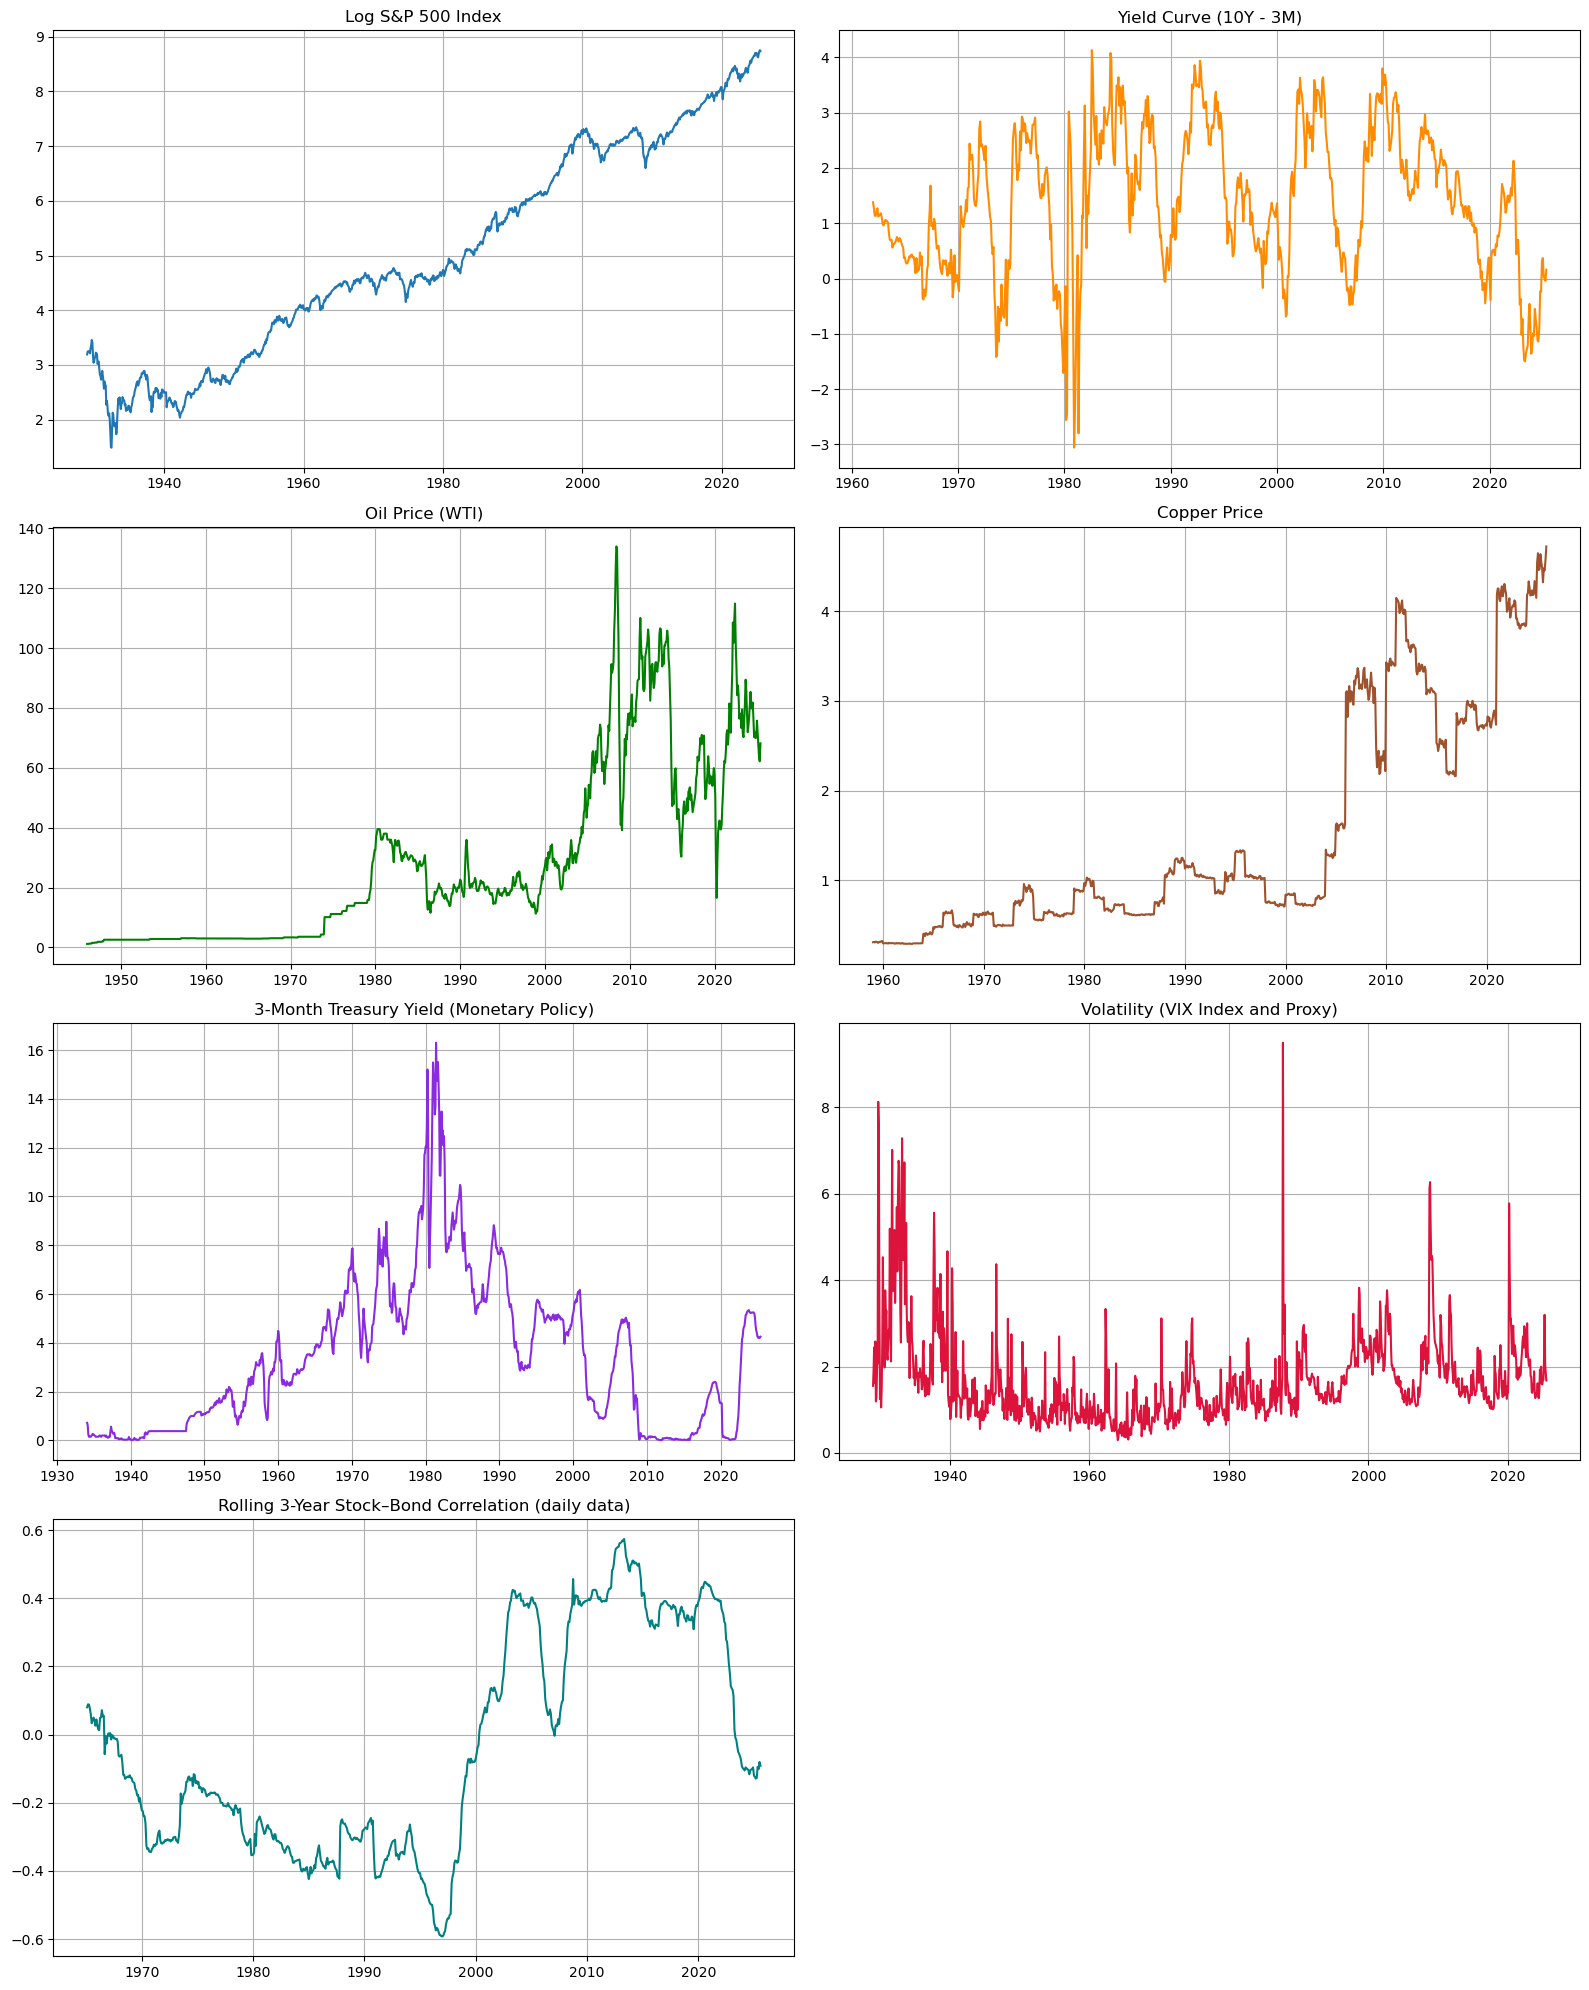

In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import matplotlib.dates   as mdates
import seaborn            as sns

to_ts = lambda p: p.to_timestamp(how="end")

# ======================================================================
# 1.  S&P 500  (daily ➜ monthly prices & returns)
# ======================================================================
sp_daily = (pd.read_excel(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\sp500.xlsx",
                        usecols=["Dates", "PX_LAST"])
              .rename(columns={"Dates": "Date",
                               "PX_LAST": "SP500_Price"}))
sp_daily["Date"] = pd.to_datetime(sp_daily["Date"])

sp_daily["ret"]  = np.log(sp_daily["SP500_Price"]).diff()

sp_daily["Month"] = sp_daily["Date"].dt.to_period("M")
sp_monthly = (sp_daily
              .groupby("Month")
              .tail(1)          
              .reset_index(drop=True))

sp_monthly["SP500_Return"] = np.log(sp_monthly["SP500_Price"]).diff()
sp_monthly["Log_SP500"]    = np.log(sp_monthly["SP500_Price"])

var_mkt = sp_monthly[["Month", "SP500_Price",
                      "SP500_Return", "Log_SP500"]].copy()

# ======================================================================
# 2.  10-YEAR YIELD  (daily ➜ monthly)
# ======================================================================
bond_daily = (pd.read_csv(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\10yUS.csv",
                          usecols=["observation_date", "DGS10"])
                .rename(columns={"observation_date": "Date",
                                 "DGS10": "TenYear"}))

bond_daily["Date"] = pd.to_datetime(bond_daily["Date"])
bond_daily["TenYear"] = pd.to_numeric(bond_daily["TenYear"],
                                      errors="coerce")

bond_daily["Month"] = bond_daily["Date"].dt.to_period("M")

# last non-NaN within each month
tenyear_monthly = (
    bond_daily
    .dropna(subset=["TenYear"])
    .sort_values(["Month", "Date"])
    .groupby("Month", as_index=False)
    .agg(TenYear=("TenYear", "last"))
)


# ======================================================================
# 3.  3-MONTH BILL (monthly, unchanged)
# ======================================================================
var_3m = (pd.read_csv(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\3mUS.csv",
                      usecols=["observation_date", "TB3MS"])
            .rename(columns={"observation_date": "Date",
                             "TB3MS": "ThreeMonth"}))
var_3m["Date"]  = pd.to_datetime(var_3m["Date"])
var_3m["ThreeMonth"] = pd.to_numeric(var_3m["ThreeMonth"], errors="coerce")
var_3m["Month"] = var_3m["Date"].dt.to_period("M")
var_3m = var_3m[["Month", "ThreeMonth"]]

# ======================================================================
# 4.  YIELD-CURVE VARIABLES  (10y − 3m, Δ10y)
# ======================================================================
merged = (tenyear_monthly
          .merge(var_3m, on="Month", how="inner")
          .sort_values("Month"))

merged["YieldCurve"]  = merged["TenYear"] - merged["ThreeMonth"]
merged["YieldChange"] = merged["TenYear"].diff()

# ======================================================================
# 5.  OIL  (unchanged: monthly average)
# ======================================================================
var_oil = (pd.read_csv(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\Oil U.S.csv")
             .rename(columns={"observation_date": "Date",
                              "WTISPLC": "Oil Price"}))
var_oil["Date"] = pd.to_datetime(var_oil["Date"])
var_oil["Oil Price"] = pd.to_numeric(var_oil["Oil Price"], errors="coerce")
var_oil["Month"] = var_oil["Date"].dt.to_period("M")
oil_monthly = (var_oil
               .groupby("Month")["Oil Price"]
               .mean()
               .reset_index())

# ======================================================================
# 6.  COPPER  (unchanged: monthly average)
# ======================================================================
var_copper = pd.read_csv(
    r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\copper-prices-historical-chart-data.csv")
var_copper.rename(columns={var_copper.columns[0]: "Date",
                           var_copper.columns[1]: "Copper"},
                  inplace=True)
var_copper["Date"]   = pd.to_datetime(var_copper["Date"],
                                      dayfirst=True, errors="coerce")
var_copper["Copper"] = pd.to_numeric(var_copper["Copper"], errors="coerce")
var_copper["Month"]  = var_copper["Date"].dt.to_period("M")
copper_monthly = (var_copper
                  .groupby("Month")["Copper"]
                  .mean()
                  .reset_index())


# ======================================================================
# 7.  VIX (daily ➜ monthly)  +  REALISED-VOL PROXY (daily pre-1990)
# ======================================================================
# --- 7a. Bloomberg VIX (daily)  ---------------------------------------
var_VIX = (pd.read_excel(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\VIX.xlsx",
                         usecols=["Dates", "PX_LAST"])
             .rename(columns={"Dates": "Date", "PX_LAST": "VIX"}))
var_VIX["Date"] = pd.to_datetime(var_VIX["Date"])
var_VIX["VIX"]  = pd.to_numeric(var_VIX["VIX"], errors="coerce")

var_VIX["Month"] = var_VIX["Date"].dt.to_period("M")
vix_monthly = (var_VIX
               .groupby("Month")["VIX"]
               .mean()
               .div(10)
               .rename("VolProxy")  
               .reset_index())

# --- 7b. Realised volatility from DAILY S&P 500 returns ---------------
first_vix_month = vix_monthly["Month"].min()

realised = (
    sp_daily
      .loc[sp_daily["Month"] < first_vix_month]
      .groupby("Month")["ret"]
      .agg(lambda x: x.std(ddof=0) * np.sqrt(252) * 10)
      .to_frame("VolProxy")
      .reset_index()
)
# --- 7c. Stitch realised-vol with VIX ---------------------------------
combined_vol = (pd.concat([realised, vix_monthly], axis=0)
                  .sort_values("Month")
                  .reset_index(drop=True))

# ======================================================================
# 8.  STOCK–BOND CORRELATION  (daily ➜ monthly, paper’s method)
# ======================================================================
df_daily = (sp_daily[["Date", "ret"]]
              .merge(bond_daily[["Date", "TenYear"]], on="Date",
                     how="inner")
              .dropna())
df_daily["d_y"] = df_daily["TenYear"].diff() / 100.0
df_daily.dropna(inplace=True)

window_days = 252 * 3
df_daily["StockBondCorr"] = (df_daily["ret"]
                               .rolling(window_days)
                               .corr(df_daily["d_y"]))

df_daily["Month"] = df_daily["Date"].dt.to_period("M")
var_correl = (df_daily.dropna(subset=["StockBondCorr"])
                .groupby("Month")
                .tail(1)
                [["Month", "StockBondCorr"]]
                .reset_index(drop=True))

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
axes = axes.flatten()  

# 1. Log S&P500
var_mkt_latest = var_mkt.drop_duplicates('Month', keep='last')
axes[0].plot(var_mkt_latest['Month'].dt.to_timestamp(), 
             np.log(var_mkt_latest['SP500_Price']), label='Log S&P 500')
axes[0].set_title("Log S&P 500 Index")
axes[0].grid()

# 2. Yield Curve
axes[1].plot(merged['Month'].dt.to_timestamp(), merged['YieldCurve'], label='Yield Curve', color='darkorange')
axes[1].set_title("Yield Curve (10Y - 3M)")
axes[1].grid()

# 3. Oil Price
axes[2].plot(oil_monthly['Month'].dt.to_timestamp(), oil_monthly['Oil Price'], label='Oil Price', color='green')
axes[2].set_title("Oil Price (WTI)")
axes[2].grid()

# 4. Copper Price
axes[3].plot(copper_monthly['Month'].dt.to_timestamp(), copper_monthly['Copper'], label='Copper Price', color='sienna')
axes[3].set_title("Copper Price")
axes[3].grid()

# 5. 3-Month Treasury Yield  ← use Month ➜ timestamp
axes[4].plot(
    var_3m['Month'].dt.to_timestamp(how='end'),   # <-- was var_3m['Date']
    var_3m['ThreeMonth'],
    label='3M Treasury Yield',
    color='blueviolet'
)
axes[4].set_title("3-Month Treasury Yield (Monetary Policy)")
axes[4].grid()
# 6. VIX (Volatility)
axes[5].plot(combined_vol['Month'].dt.to_timestamp(), combined_vol['VolProxy'], label='VIX', color='crimson')
axes[5].set_title("Volatility (VIX Index and Proxy)")
axes[5].grid()

# 7. Stock–Bond Correlation  ← update title to reflect 3-year daily window
axes[6].plot(
    var_correl['Month'].dt.to_timestamp(how='end'),
    var_correl['StockBondCorr'],
    label='Stock–Bond Corr.',
    color='teal'
)
axes[6].set_title("Rolling 3-Year Stock–Bond Correlation (daily data)")
axes[6].grid()

axes[7].axis('off')  
plt.tight_layout()
plt.show()

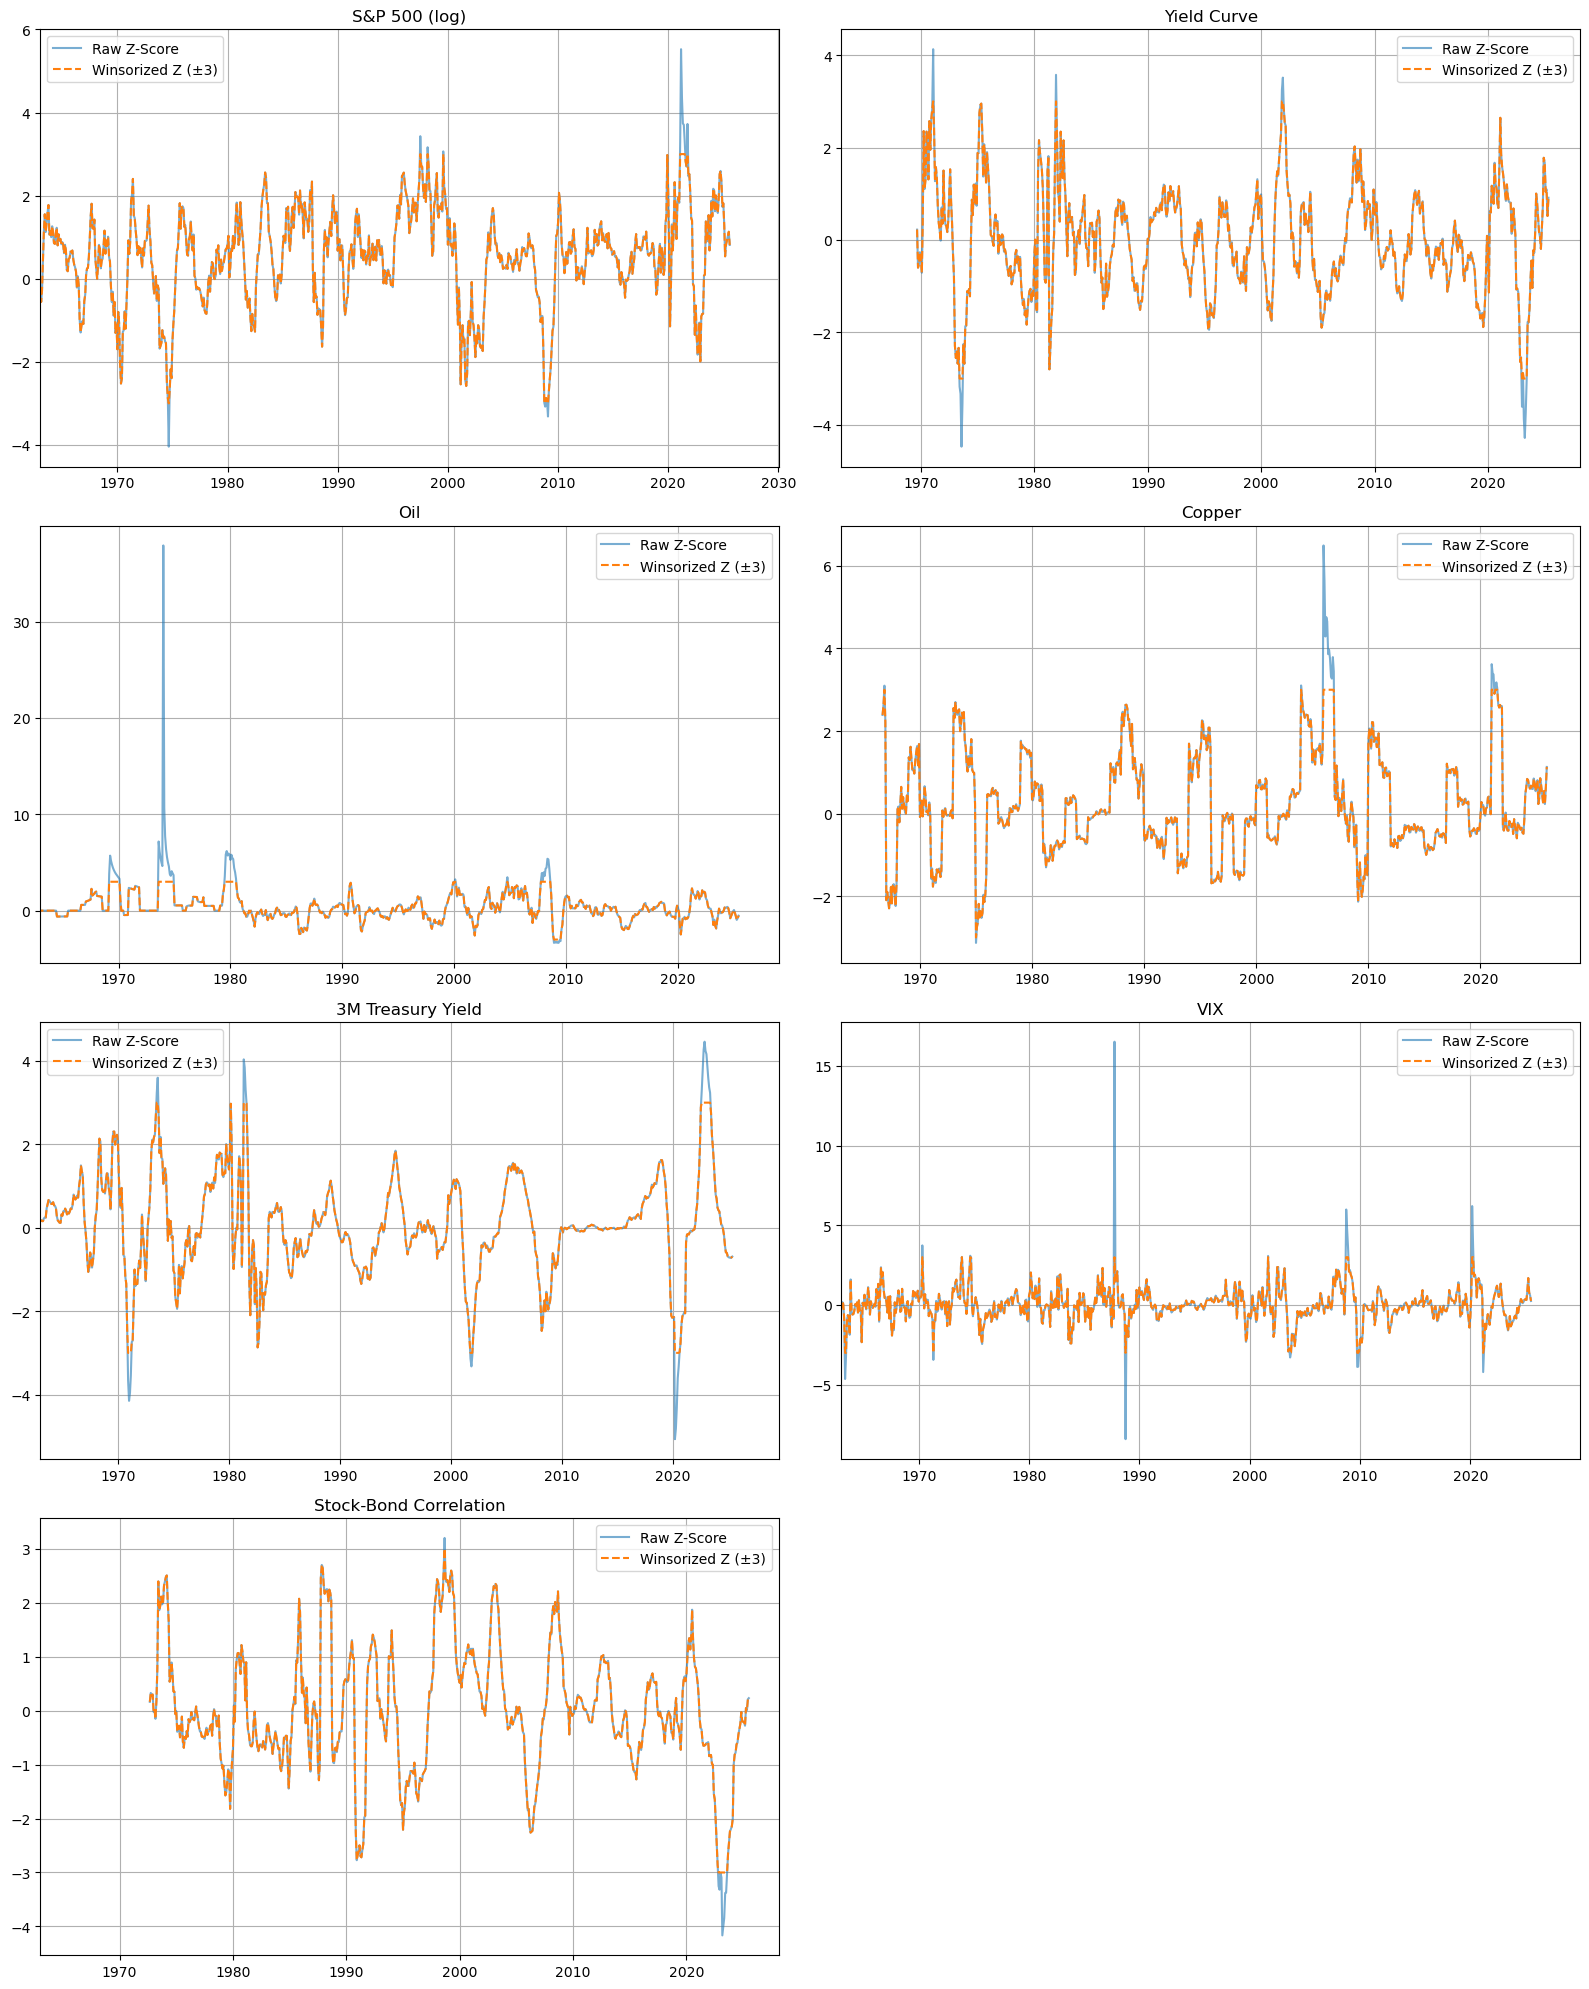

In [4]:
def compute_z_and_winsorized(df, date_col, value_col, window_months=120):
    df = df.copy().sort_values(date_col)
    df['Diff12'] = df[value_col] - df[value_col].shift(12)
    df['RollStd'] = df['Diff12'].shift(1).rolling(window_months,min_periods=80).std()
    df['ZScore'] = df['Diff12'] / df['RollStd']
    df['ZScoreWinsorized'] = df['ZScore'].clip(-3, 3)
    return df[[date_col, 'ZScore', 'ZScoreWinsorized']]


series_info = {
    'S&P 500 (log)':         ('sp500_log',      var_mkt,      'Month', 'Log_SP500'),
    'Yield Curve':           ('yield_curve',    merged,         'Month', 'YieldCurve'),
    'Oil':                   ('oil',            oil_monthly,    'Month', 'Oil Price'),
    'Copper':                ('copper',         copper_monthly, 'Month', 'Copper'),
    '3M Treasury Yield':     ('three_month',    var_3m,     'Month', 'ThreeMonth'),
    'VIX':                   ('vix',            combined_vol,   'Month', 'VolProxy'),
    'Stock-Bond Correlation':('stockbond_corr', var_correl,     'Month', 'StockBondCorr'),
}

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, (title, (_, df, date_col, value_col)) in enumerate(series_info.items()):
    z_df = compute_z_and_winsorized(df, date_col, value_col)
    axes[i].plot(z_df[date_col].dt.to_timestamp(), z_df['ZScore'], label='Raw Z-Score', alpha=0.6)
    axes[i].plot(z_df[date_col].dt.to_timestamp(), z_df['ZScoreWinsorized'], label='Winsorized Z (±3)',ls = '--')
    axes[i].set_title(title)
    axes[i].set_xlim(left=pd.Timestamp('1963-01-01'))
    axes[i].grid(True)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [6]:

market_monthly = (var_mkt
                  .loc[:, ["Month", "Log_SP500"]]
                  .rename(columns={"Log_SP500": "Value"}))

yield_monthly = (merged
                 .loc[:, ["Month", "YieldCurve"]]
                 .rename(columns={"YieldCurve": "Value"}))

oil_monthly_clean = oil_monthly.rename(columns={"Oil Price": "Value"})

copper_monthly_clean = copper_monthly.rename(columns={"Copper": "Value"})

monthly_3m = (var_3m
              .loc[:, ["Month", "ThreeMonth"]]
              .rename(columns={"ThreeMonth": "Value"}))

vix_monthly_clean = combined_vol.rename(columns={"VolProxy": "Value"})

stockbond_monthly = (var_correl
                     .loc[:, ["Month", "StockBondCorr"]]
                     .rename(columns={"StockBondCorr": "Value"}))


series_dict = {
    'Market':               market_monthly, 
    'Yield curve':          yield_monthly,
    'Oil':                  oil_monthly_clean,
    'Copper':               copper_monthly_clean,
    '3M Treasury Yield':    monthly_3m,
    'VIX':                  vix_monthly_clean,
    'Stock-Bond Corr':      stockbond_monthly
}




rows = []
lags = [1, 3, 12, 36, 120]

for i, (title, (_, df, date_col, value_col)) in enumerate(series_info.items()):

    zdf = compute_z_and_winsorized(df, date_col, value_col).dropna(subset=['ZScoreWinsorized']).reset_index(drop=True)
    
    if len(zdf) < max(lags) + 1:
        acs = [np.nan] * len(lags)
        mean_z = np.nan
        std_z = np.nan
    else:
        acs = [zdf['ZScoreWinsorized'].autocorr(lag=lag) for lag in lags]
        mean_z = zdf['ZScoreWinsorized'].mean()
        std_z = zdf['ZScoreWinsorized'].std(ddof=1)  
    
    rows.append({
        'Variable':    title,
        '1 month':     acs[0],
        '3 month':     acs[1],
        '12 month':    acs[2],
        '3 year':      acs[3],
        '10 year':     acs[4],
        'monthly mean': mean_z,
        'std':          std_z,
        'frequency':   'monthly'
    })


summary_table = pd.DataFrame(rows)

summary_table = summary_table[
    ['Variable', '1 month', '3 month', '12 month', '3 year', '10 year',
     'monthly mean', 'std', 'frequency']
]

numeric_cols = ['1 month', '3 month', '12 month', '3 year', '10 year', 'monthly mean', 'std']
summary_table[numeric_cols] = summary_table[numeric_cols].round(2)

summary_table




,Variable,1 month,3 month,12 month,3 year,10 year,monthly mean,std,frequency
0,S&P 500 (log),0.93,0.78,0.00,0.04,-0.01,0.49,1.06,monthly
1,Yield Curve,0.90,0.73,-0.11,-0.25,0.04,-0.02,1.11,monthly
2,Oil,0.93,0.73,-0.04,0.15,-0.02,0.33,1.19,monthly
3,Copper,0.91,0.75,0.08,-0.08,0.02,0.22,1.19,monthly
4,3M Treasury Yield,0.96,0.82,0.02,-0.18,0.06,0.19,1.24,monthly
5,VIX,0.63,0.31,-0.36,-0.07,-0.04,0.01,0.92,monthly
6,Stock-Bond Correlation,0.96,0.83,0.13,-0.35,0.13,-0.00,1.16,monthly


       Month    Market  Yield curve       Oil    Copper  Monetary policy  \
500  1970-08 -1.238848     2.204655 -0.455185  0.038849        -0.687742   
501  1970-09 -0.780197     1.311288 -0.454050  0.070223        -1.179011   
502  1970-10 -1.202042     2.571971 -0.452930 -0.041388        -1.340827   
503  1970-11 -0.561880     1.951274 -0.451825  0.271582        -2.447778   
504  1970-12  0.007505     2.597356  2.366354 -0.006738        -3.000000   

     Volatility  Stock-bond  
500    0.672586         NaN  
501    0.103528         NaN  
502    0.323677         NaN  
503    0.323033         NaN  
504   -0.697855         NaN  


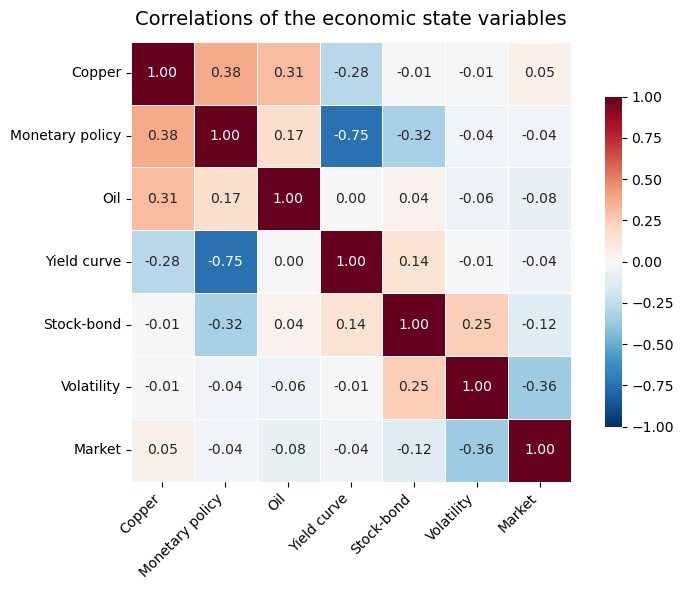

In [7]:
z_market  = compute_z_and_winsorized(market_monthly,      'Month', 'Value',          window_months=120) \
                .rename(columns={'ZScoreWinsorized':'Market'})[['Month','Market']]

z_yield   = compute_z_and_winsorized(yield_monthly,       'Month', 'Value',          window_months=120) \
                .rename(columns={'ZScoreWinsorized':'Yield curve'})[['Month','Yield curve']]

z_oil     = compute_z_and_winsorized(oil_monthly_clean,   'Month', 'Value',          window_months=120) \
                .rename(columns={'ZScoreWinsorized':'Oil'})[['Month','Oil']]

z_copper  = compute_z_and_winsorized(copper_monthly_clean,'Month', 'Value',          window_months=120) \
                .rename(columns={'ZScoreWinsorized':'Copper'})[['Month','Copper']]

z_3m      = compute_z_and_winsorized(monthly_3m,          'Month', 'Value',          window_months=120) \
                .rename(columns={'ZScoreWinsorized':'Monetary policy'})[['Month','Monetary policy']]

z_vix     = compute_z_and_winsorized(vix_monthly_clean,    'Month', 'Value',          window_months=120) \
                .rename(columns={'ZScoreWinsorized':'Volatility'})[['Month','Volatility']]

z_sb      = compute_z_and_winsorized(stockbond_monthly,    'Month', 'Value',  window_months=120) \
                .rename(columns={'ZScoreWinsorized':'Stock-bond'})[['Month','Stock-bond']]

df_period = (
    z_market
    .merge(z_yield, on='Month', how='outer')
    .merge(z_oil, on='Month', how='outer')
    .merge(z_copper, on='Month', how='outer')
    .merge(z_3m, on='Month', how='outer')
    .merge(z_vix, on='Month', how='outer')
    .merge(z_sb, on='Month', how='outer')
)

print(df_period[500:505])
corr_mat = df_period.drop(columns='Month').corr()


row_order = [
    'Copper',
    'Monetary policy',
    'Oil',
    'Yield curve',
    'Stock-bond',
    'Volatility',
    'Market'
]
corr_mat = corr_mat.loc[row_order, row_order]

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_mat,
    annot=True,
    fmt='.2f',
    center=0,
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.75}
)
plt.title('Correlations of the economic state variables', fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [9]:
def find_similar_months(
    df_period: pd.DataFrame,
    target: str,
    exclude_last_n: int = 36,
    bottom_pct: float = 0.20
) -> pd.DataFrame:
    
    T_period = pd.Period(target, freq='M')

    
    cutoff_period = T_period - exclude_last_n  

    mask = df_period.index <= cutoff_period

    df_candidates = df_period.loc[mask].copy()

    df_candidates = df_candidates.dropna(how='any')

    z_T = df_period.loc[T_period].values   

    mat = df_candidates.values               
    diffs = mat - z_T.reshape(1, -1)        
    sq    = diffs**2
    dist  = np.sqrt(sq.sum(axis=1))          

    out = pd.DataFrame({
        'Distance': dist
    }, index=df_candidates.index)

    out = out.sort_values('Distance', ascending=True)
    out['Rank'] = np.arange(1, len(out) + 1)

    n_select = int(np.floor(bottom_pct * len(out)))
    n_select = max(n_select, 1)  # ensure at least one month is selected
    out['IsBottom'] = False
    out.iloc[:n_select, out.columns.get_indexer(['IsBottom'])] = True

    result_df = out.reset_index().rename(columns={'index': 'Month'})

    return result_df

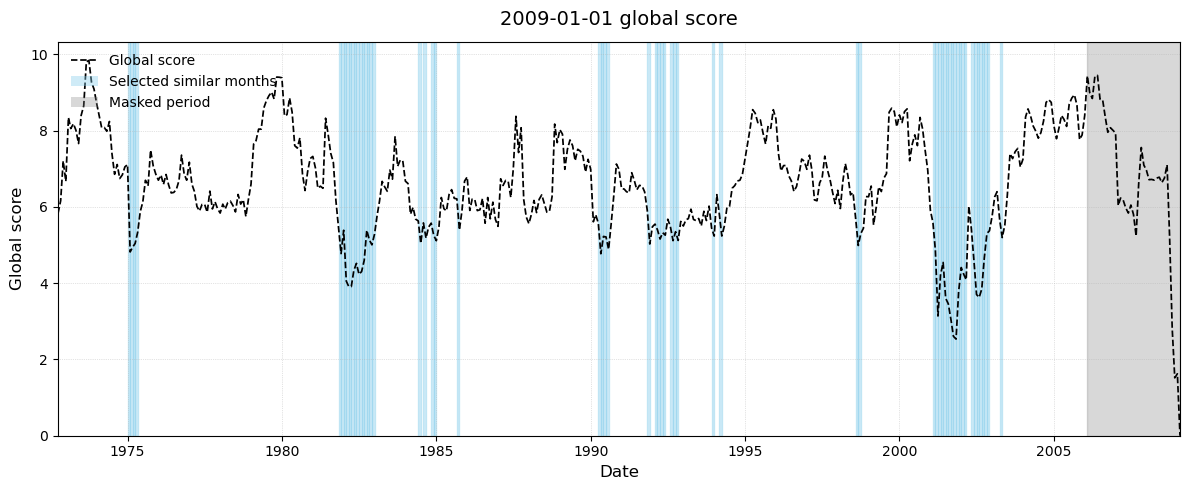

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle


target_month   = '2009-01'   
bottom_pct     = 0.15       
exclude_last_n = 36          

if 'Month' in df_period.columns:
    df_period = df_period.set_index('Month')


sim_tbl_full = find_similar_months(       
    df_period=df_period,
    target=target_month,
    exclude_last_n=0,          
    bottom_pct=bottom_pct,
)

sim_tbl_masked = find_similar_months(     
    df_period=df_period,
    target=target_month,
    exclude_last_n=exclude_last_n,
    bottom_pct=bottom_pct,
)

ts_dist = (
    sim_tbl_full.set_index('Month')['Distance']
               .sort_index()
               .rename('Global score')
)
ts_dist.index = ts_dist.index.to_timestamp(how='end')

selected = sim_tbl_masked[sim_tbl_masked['IsBottom']].copy()
selected['start'] = selected['Month'].dt.to_timestamp(how='start')
selected['end']   = selected['Month'].dt.to_timestamp(how='end')

T_period      = pd.Period(target_month, freq='M')
cutoff_period = T_period - exclude_last_n
mask_start_ts = (cutoff_period + 1).to_timestamp(how='start')
mask_end_ts   = T_period.to_timestamp(how='end')


plt.figure(figsize=(12, 5))
ax = plt.gca()

ax.plot(ts_dist.index, ts_dist.values,
        linestyle='--', color='black', linewidth=1.25,
        label='Global score')

for _, row in selected.iterrows():
    ax.axvspan(row['start'], row['end'], color='skyblue', alpha=0.4)

ax.axvspan(mask_start_ts, mask_end_ts, color='gray', alpha=0.3)

proxy_sim  = Rectangle((0, 0), 1, 1, facecolor='skyblue', alpha=0.4)
proxy_mask = Rectangle((0, 0), 1, 1, facecolor='gray',    alpha=0.3)
ax.legend(handles=[ax.lines[0], proxy_sim, proxy_mask],
          labels=['Global score', 'Selected similar months', 'Masked period'],
          loc='upper left', frameon=False)

ax.set_title('2009-01-01 global score', fontsize=14, pad=12)
ax.set_ylabel('Global score', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylim(bottom=0)           
ax.set_xlim(left=ts_dist.index.min(),
            right=ts_dist.index.max()) 

ax.grid(which='major', linestyle=':', linewidth=0.5, alpha=0.7)
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()



In [20]:

# ... your plotting code above ...
# fig, axes = plt.subplots(4, 2, figsize=(16, 20))
# ... all the axes[.] plotting ...

from pathlib import Path

# 1) Layout first
fig.tight_layout()

# 2) Ensure folder exists
outdir = Path("figures")
outdir.mkdir(parents=True, exist_ok=True)

# 3) Save the SAME figure handle
outfile = outdir / "stress_test_2009.png"
fig.savefig(outfile, dpi=300, bbox_inches="tight")

# 4) (Optional) Show and then close
plt.show()
plt.close(fig)

print(f"Saved figure to: {outfile.resolve()}")

Saved figure to: C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Research Notebook\Factors\figures\stress_test_2009.png


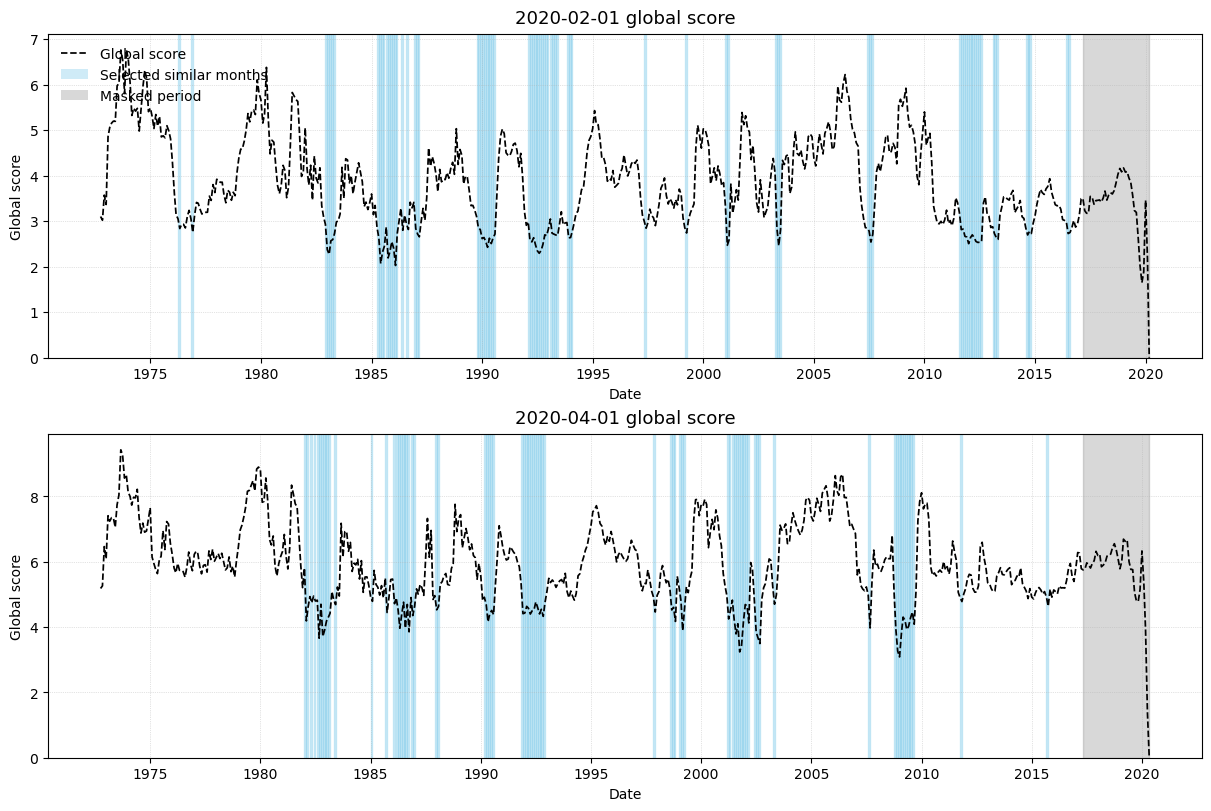

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle


targets        = ['2020-02', '2020-04']  
bottom_pct     = 0.15                    
exclude_last_n = 36                       

if 'Month' in df_period.columns:
    df_period = df_period.set_index('Month')


fig, axes = plt.subplots(
    nrows=2, ncols=1, figsize=(12, 8), sharey=False, constrained_layout=True
)

for ax, tgt_str in zip(axes, targets):

    sim_full = find_similar_months(df_period, tgt_str, exclude_last_n=0,
                                   bottom_pct=bottom_pct)
    ts_dist = (sim_full.set_index('Month')['Distance']
                       .sort_index()
                       .rename('Global score'))
    ts_dist.index = ts_dist.index.to_timestamp(how='end')

    sim_masked = find_similar_months(df_period, tgt_str,
                                     exclude_last_n=exclude_last_n,
                                     bottom_pct=bottom_pct)
    selected = sim_masked[sim_masked['IsBottom']].copy()
    selected['start'] = selected['Month'].dt.to_timestamp(how='start')
    selected['end']   = selected['Month'].dt.to_timestamp(how='end')

    Tp          = pd.Period(tgt_str, freq='M')
    mask_start  = (Tp - exclude_last_n + 1).to_timestamp(how='start')
    mask_end    = Tp.to_timestamp(how='end')

    ax.plot(ts_dist.index, ts_dist.values, '--', color='black', lw=1.25)

    for _, row in selected.iterrows():
        ax.axvspan(row['start'], row['end'], color='skyblue', alpha=0.4)

    ax.axvspan(mask_start, mask_end, color='gray', alpha=0.3)

    ax.set_ylim(bottom=0)                     
    ax.set_title(f'{tgt_str}-01 global score', fontsize=13, pad=8)
    ax.set_xlabel('Date')
    ax.set_ylabel('Global score')
    ax.grid(which='major', linestyle=':', linewidth=0.5, alpha=0.7)
    ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

proxy_sim  = Rectangle((0, 0), 1, 1, facecolor='skyblue', alpha=0.4)
proxy_mask = Rectangle((0, 0), 1, 1, facecolor='gray',    alpha=0.3)
axes[0].legend([axes[0].lines[0], proxy_sim, proxy_mask],
               ['Global score', 'Selected similar months', 'Masked period'],
               loc='upper left', frameon=False)

plt.show()



In [14]:

# ... your plotting code above ...
# fig, axes = plt.subplots(4, 2, figsize=(16, 20))
# ... all the axes[.] plotting ...

from pathlib import Path

# 1) Layout first
fig.tight_layout()

# 2) Ensure folder exists
outdir = Path("figures")
outdir.mkdir(parents=True, exist_ok=True)

# 3) Save the SAME figure handle
outfile = outdir / "stress_test_2020.png"
fig.savefig(outfile, dpi=300, bbox_inches="tight")

# 4) (Optional) Show and then close
plt.show()
plt.close(fig)

print(f"Saved figure to: {outfile.resolve()}")

C:\Users\kelvi\AppData\Local\Temp\ipykernel_15956\175454208.py:8: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


Saved figure to: C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Research Notebook\Factors\figures\stress_test_2020.png


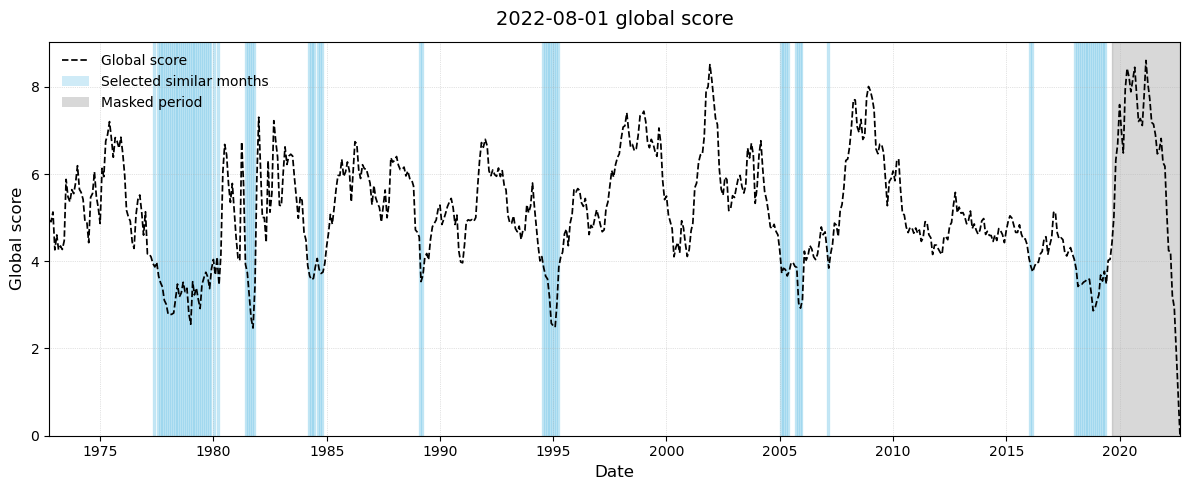

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

target_month   = '2022-08'     
bottom_pct     = 0.15          
exclude_last_n = 36           

if 'Month' in df_period.columns:
    df_period = df_period.set_index('Month')


sim_full = find_similar_months(
    df_period=df_period,
    target=target_month,
    exclude_last_n=0,            
    bottom_pct=bottom_pct,
)
ts_dist = (sim_full.set_index('Month')['Distance']
                    .sort_index()
                    .rename('Global score'))
ts_dist.index = ts_dist.index.to_timestamp(how='end')

sim_masked = find_similar_months(
    df_period=df_period,
    target=target_month,
    exclude_last_n=exclude_last_n,
    bottom_pct=bottom_pct,
)
selected = sim_masked[sim_masked['IsBottom']].copy()
selected['start'] = selected['Month'].dt.to_timestamp(how='start')
selected['end']   = selected['Month'].dt.to_timestamp(how='end')

Tp          = pd.Period(target_month, freq='M')
mask_start  = (Tp - exclude_last_n + 1).to_timestamp(how='start')
mask_end    = Tp.to_timestamp(how='end')


plt.figure(figsize=(12, 5))
ax = plt.gca()

ax.plot(ts_dist.index, ts_dist.values,
        linestyle='--', color='black', linewidth=1.25,
        label='Global score')

for _, row in selected.iterrows():
    ax.axvspan(row['start'], row['end'], color='skyblue', alpha=0.4)

ax.axvspan(mask_start, mask_end, color='gray', alpha=0.3)

proxy_sim  = Rectangle((0, 0), 1, 1, facecolor='skyblue', alpha=0.4)
proxy_mask = Rectangle((0, 0), 1, 1, facecolor='gray',    alpha=0.3)
ax.legend([ax.lines[0], proxy_sim, proxy_mask],
          ['Global score', 'Selected similar months', 'Masked period'],
          loc='upper left', frameon=False)

ax.set_title('2022-08-01 global score', fontsize=14, pad=12)
ax.set_ylabel('Global score', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylim(bottom=0)                            
ax.set_xlim(left=ts_dist.index.min(),
            right=ts_dist.index.max())            
ax.grid(which='major', linestyle=':', linewidth=0.5, alpha=0.7)
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()



In [18]:

# ... your plotting code above ...
# fig, axes = plt.subplots(4, 2, figsize=(16, 20))
# ... all the axes[.] plotting ...

from pathlib import Path

# 1) Layout first
fig.tight_layout()

# 2) Ensure folder exists
outdir = Path("figures")
outdir.mkdir(parents=True, exist_ok=True)

# 3) Save the SAME figure handle
outfile = outdir / "stress_test_2022.png"
fig.savefig(outfile, dpi=300, bbox_inches="tight")

# 4) (Optional) Show and then close
plt.show()
plt.close(fig)

print(f"Saved figure to: {outfile.resolve()}")

Saved figure to: C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Research Notebook\Factors\figures\stress_test_2022.png


In [23]:
ff_5f = pd.read_csv(r"C:\Users\kelvi\Downloads\F-F_Research_Data_5_Factors_2x3_CSV\F-F_Research_Data_5_Factors_2x3.csv")
ff_mom = pd.read_csv(r"C:\Users\kelvi\Downloads\F-F_Momentum_Factor_CSV\F-F_Momentum_Factor.csv")


In [24]:
concat_fff = pd.merge(ff_5f, ff_mom, on='Unnamed: 0', how='inner')
concat_fff.rename(columns={'Unnamed: 0': 'Date'}, inplace = True)

mask_valid = concat_fff['Date'].astype(str).str.match(r'^\d{6}$')
concat_fff = concat_fff.loc[mask_valid].copy()

concat_fff['Date'] = concat_fff['Date'].astype(str)
concat_fff['Month'] = concat_fff['Date'].apply(lambda x: pd.Period(x, freq='M'))
factor_cols = ['Mkt-RF','SMB','HML','RMW','CMA','Mom']
for col in factor_cols:
    concat_fff[col] = pd.to_numeric(concat_fff[col], errors='coerce') / 100.0

concat_fff['RF'] = pd.to_numeric(concat_fff['RF'], errors='coerce') / 100.0
concat_fff = concat_fff.set_index('Month')
concat_fff.drop(columns=['Date'], inplace=True)
concat_fff.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
Month,,,,,,,
1963-07,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,0.0101
1963-08,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0100
1963-09,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,0.0012
1963-10,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0313
1963-11,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0078


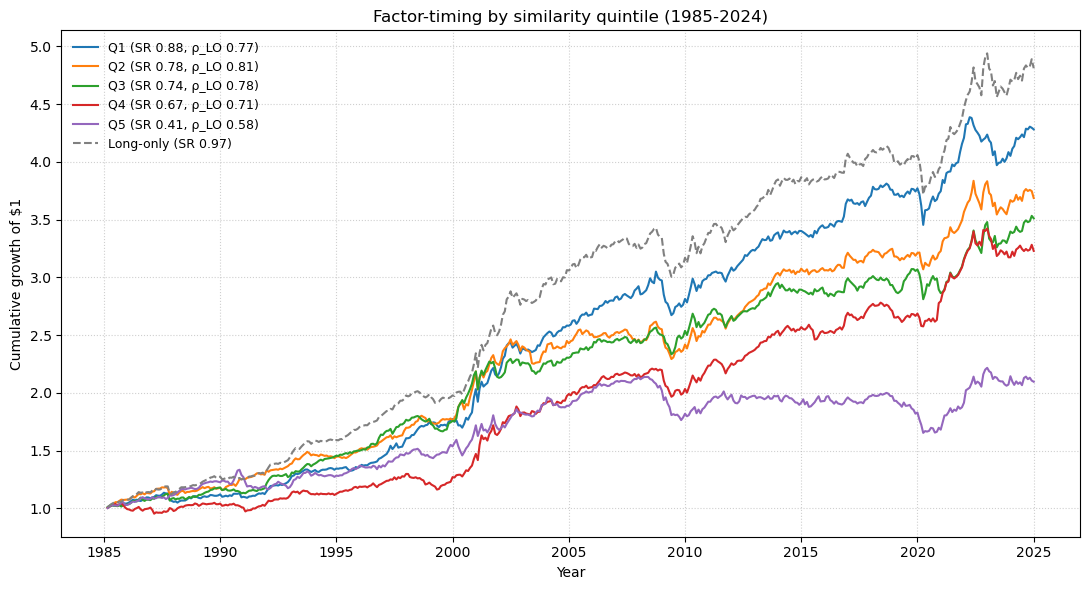

In [25]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

lookback_gap  = 36                             
factors       = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
colors        = {1:"tab:blue", 2:"tab:orange", 3:"tab:green",
                 4:"tab:red", 5:"tab:purple"}

BACKTEST_START = pd.Period('1985-01', freq='M')
BACKTEST_END   = pd.Period('2024-12', freq='M')

def quintile_members(df_period: pd.DataFrame, target_per: pd.Period):
    """
    Return dict{1…5 → ndarray of months} following the paper’s rules:
      • Q1 = closest 20 %
      • Q5 = farthest 20 %
      • Q2-Q4 = equal thirds of the middle 60 %
    """
    full = find_similar_months(
        df_period      = df_period,
        target         = str(target_per),
        exclude_last_n = lookback_gap,
        bottom_pct     = 1.0             
    ).sort_values("Distance")            

    n = len(full)
    if n == 0:                          
        return {q: np.array([]) for q in range(1, 6)}

    k20 = int(0.20 * n)
    q1  = full.iloc[:k20]['Month'].to_numpy()
    q5  = full.iloc[-k20:]['Month'].to_numpy()

    mid = full.iloc[k20:-k20]['Month'].to_numpy()
    q2, q3, q4 = np.array_split(mid, 3)

    return {1: q1, 2: q2, 3: q3, 4: q4, 5: q5}

def signal_for_quintile(df_period, target_per, quintile):
    months = quintile_members(df_period, target_per)[quintile]
    if len(months) == 0:
        return {f: 0 for f in factors}

    idx = pd.PeriodIndex(months, freq="M") + 1         
    signs = {}
    for f in factors:
        rets = concat_fff.loc[concat_fff.index.intersection(idx), f]
        signs[f] = np.sign(rets.mean()) if not rets.empty else 0
    return signs

first_possible = df_period.index.min() + (lookback_gap + 1)
hist_start     = max(BACKTEST_START, first_possible)
hist_end       = min(BACKTEST_END,   concat_fff.index.max())

all_months = concat_fff.index.sort_values()
start_idx  = next(i for i, per in enumerate(all_months) if per >= hist_start)
stop_idx   = next(i for i, per in enumerate(all_months) if per >  hist_end) - 1

returns_by_q = {q: [] for q in range(1, 6)}

for i in range(start_idx, stop_idx):
    cur_per = all_months[i]
    nxt_per = all_months[i + 1]
    r       = concat_fff.loc[nxt_per, factors]

    for q in range(1, 6):
        sig = signal_for_quintile(df_period, cur_per, q)
        ret = np.mean([sig[f] * r[f] for f in factors])
        returns_by_q[q].append({"Date": nxt_per, "Return": ret})

q_df = {q: pd.DataFrame(lst).set_index("Date") for q, lst in returns_by_q.items()}

long_only = concat_fff[factors].mean(axis=1).loc[q_df[1].index]

ann_sr  = lambda x: (x.mean() / x.std()) * np.sqrt(12) if x.std() != 0 else np.nan
corr_lo = lambda x: x.corr(long_only)

stats = {q: (ann_sr(df["Return"]), corr_lo(df["Return"])) for q, df in q_df.items()}
sr_lo = ann_sr(long_only)

cum = lambda x: (1 + x).cumprod()

plt.figure(figsize=(11, 6))
for q in range(1, 6):
    plt.plot(q_df[q].index.to_timestamp(how="end"),
             cum(q_df[q]["Return"]),
             color=colors[q],
             label=f"Q{q} (SR {stats[q][0]:.2f}, ρ_LO {stats[q][1]:.2f})")

plt.plot(q_df[1].index.to_timestamp(how="end"),
         cum(long_only), color="gray", ls="--",
         label=f"Long-only (SR {sr_lo:.2f})")

plt.title("Factor-timing by similarity quintile (1985-2024)")
plt.xlabel("Year")
plt.ylabel("Cumulative growth of $1")
plt.legend(frameon=False, fontsize=9)
plt.grid(ls=":", alpha=.6)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


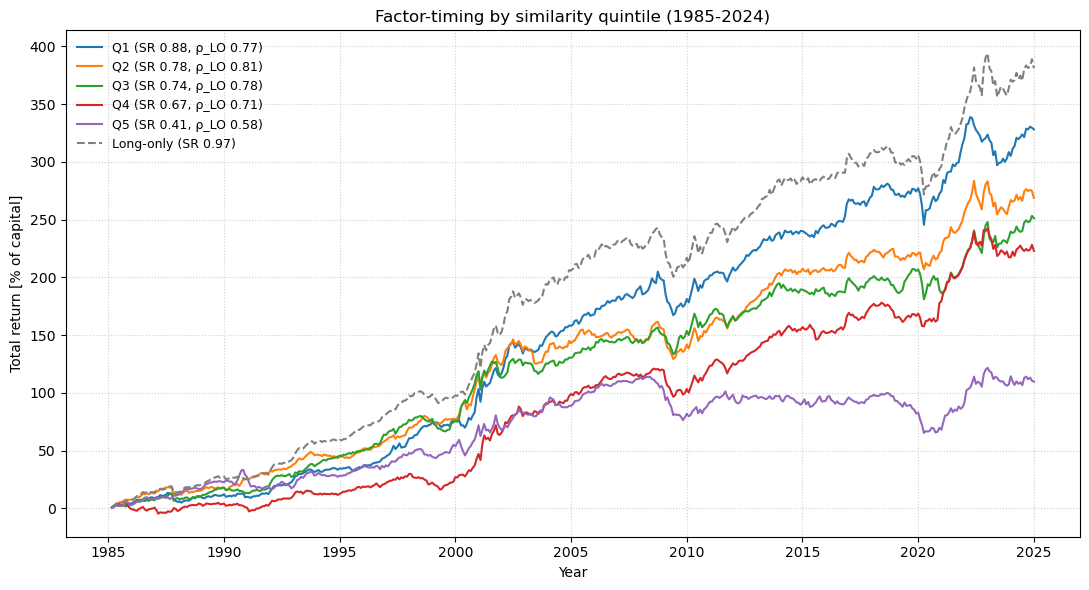

In [26]:
cum_pct = lambda x: ((1 + x).cumprod() - 1) * 100      
plt.figure(figsize=(11, 6))
for q in range(1, 6):
    plt.plot(q_df[q].index.to_timestamp(how="end"),
             cum_pct(q_df[q]["Return"]),
             color=colors[q],
             label=f"Q{q} (SR {stats[q][0]:.2f}, ρ_LO {stats[q][1]:.2f})")

plt.plot(q_df[1].index.to_timestamp(how="end"),
         cum_pct(long_only), color="gray", ls="--",
         label=f"Long-only (SR {sr_lo:.2f})")

plt.title("Factor-timing by similarity quintile (1985-2024)")
plt.xlabel("Year")
plt.ylabel("Total return [% of capital]")
plt.legend(frameon=False, fontsize=9)
plt.grid(ls=":", alpha=.6)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


             Ann. Sharpe  Corr vs LO
Long (Q1)          0.881       0.771
Short (Q5)         0.411       0.585
L–S (Q1–Q5)        0.370       0.098
Long-only          0.972         NaN


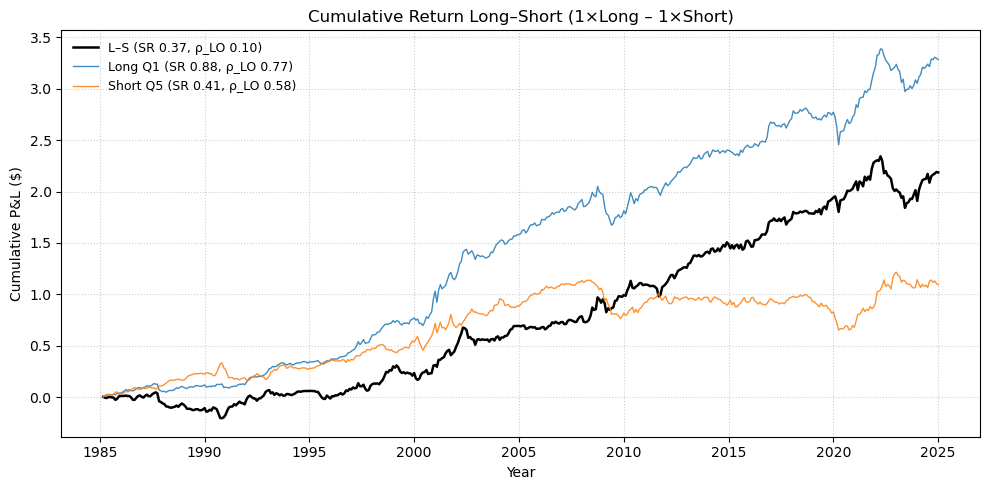

In [31]:
# --- Build aligned leg returns (Q1 long, Q5 short) ---
idx = q_df[1].index.intersection(q_df[5].index)
r_long  = q_df[1]["Return"].reindex(idx)          # monthly returns of Q1
r_short = q_df[5]["Return"].reindex(idx)          # monthly returns of Q5
r_ls    = r_long - r_short                        # monthly L-S returns (1×long, 1×short)

# --- Wealth of each leg (growth of $1) ---
cum_long  = (1 + r_long).cumprod() - 1
cum_short = (1 + r_short).cumprod() - 1
pnl_1v1   = cum_long - cum_short                  # $ P&L of 1 long – 1 short

# --- Benchmark aligned (monthly returns) ---
bench = long_only.reindex(idx)                    # monthly long-only return series
cum_bench = (1 + bench).cumprod() - 1

# --- Stats: annualized Sharpe & corr vs long-only (monthly → √12) ---
def ann_sr(x):
    s = x.std(ddof=1)
    return (x.mean()/s)*np.sqrt(12) if s and s != 0 else np.nan

stats = {
    "Long (Q1)": {
        "Ann. Sharpe": ann_sr(r_long),
        "Corr vs LO":  r_long.corr(bench)
    },
    "Short (Q5)": {
        # Sharpe for *short strategy* as a P&L trade is based on -r_short
        "Ann. Sharpe": ann_sr(r_short),
        "Corr vs LO":  (r_short).corr(bench)
    },
    "L–S (Q1–Q5)": {
        "Ann. Sharpe": ann_sr(r_ls),
        "Corr vs LO":  r_ls.corr(bench)
    },
    "Long-only": {
        "Ann. Sharpe": ann_sr(bench),
        "Corr vs LO":  np.nan
    }
}

import pandas as pd
stats_df = pd.DataFrame(stats).T.round(3)
print(stats_df)

# --- Plot ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

time = idx.to_timestamp(how="end")

plt.figure(figsize=(10, 5))
plt.plot(time, pnl_1v1, lw=1.8,
         label=f"L–S (SR {stats['L–S (Q1–Q5)']['Ann. Sharpe']:.2f}, "
               f"ρ_LO {stats['L–S (Q1–Q5)']['Corr vs LO']:.2f})",
         color='black')
plt.plot(time, cum_long,  lw=1.0, alpha=0.85,
         label=f"Long Q1 (SR {stats['Long (Q1)']['Ann. Sharpe']:.2f}, "
               f"ρ_LO {stats['Long (Q1)']['Corr vs LO']:.2f})")
plt.plot(time, cum_short, lw=1.0, alpha=0.85,
         label=f"Short Q5 (SR {stats['Short (Q5)']['Ann. Sharpe']:.2f}, "
               f"ρ_LO {stats['Short (Q5)']['Corr vs LO']:.2f})")
# Optional: benchmark wealth
# plt.plot(time, cum_bench, color="gray", ls="--",
#          label=f"Long-only (SR {stats['Long-only']['Ann. Sharpe']:.2f})")

plt.title("Cumulative Return Long–Short (1×Long – 1×Short)")
plt.xlabel("Year")
plt.ylabel("Cumulative P&L ($)")
plt.grid(ls=":", alpha=.6)
plt.legend(frameon=False, fontsize=9)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


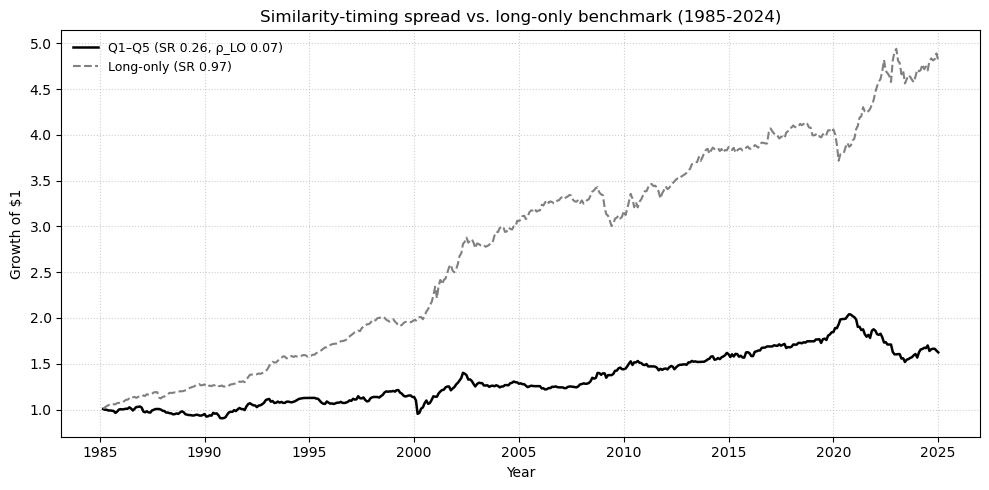

In [45]:

q_spread = q_df[1]["Return"] - q_df[5]["Return"]
q_spread.name = "Q1–Q5"

ann_sr = lambda x: (x.mean() / x.std(ddof=1)) * np.sqrt(12)

sr_spread   = ann_sr(q_spread)
corr_spread = q_spread.corr(long_only.reindex_like(q_spread))

cum = lambda x: (1 + x).cumprod()
time = q_spread.index.to_timestamp(how="end")

plt.figure(figsize=(10, 5))

plt.plot(time,
         cum(q_spread),
         color="black", lw=1.8,
         label=f"Q1–Q5 (SR {sr_spread:.2f}, ρ_LO {corr_spread:.2f})")

plt.plot(time,
         cum(long_only.reindex_like(q_spread)),
         color="gray", ls="--",
         label=f"Long-only (SR {sr_lo:.2f})")

plt.title("Similarity-timing spread vs. long-only benchmark (1985-2024)")
plt.xlabel("Year")
plt.ylabel("Growth of $1")
plt.grid(ls=":", alpha=.6)
plt.legend(frameon=False, fontsize=9)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()



In [99]:
# Load (monthly FF files often need skiprows; adjust if needed)
ff_5f_eur = (
    pd.read_csv(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Europe\Europe_5_Factors.csv",
                engine='python')
      .rename(columns={"Unnamed: 0": "Date"})
)

ff_mom_eur = (
    pd.read_csv(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Europe\Europe_MOM_Factor.csv",
                engine='python')
      .rename(columns={"Unnamed: 0": "Date"})
)

# Merge on the raw Date text
concat_fff = pd.merge(ff_5f_eur, ff_mom_eur, on='Date', how='inner')

# ---- Clean Date to Period[M] robustly ----
# 1) pull the first 6 consecutive digits if present
date6 = concat_fff['Date'].astype(str).str.extract(r'(\d{6})', expand=False)

# 2) parse to datetime then to monthly Period; rows that can't parse become NaT and will be dropped
month = pd.to_datetime(date6, format='%Y%m', errors='coerce').dt.to_period('M')

# 3) keep only valid months
concat_fff = concat_fff.loc[month.notna()].copy()
concat_fff['Month'] = month[month.notna()]

# ---- Convert factor columns to decimals and index by Month ----
factor_cols = ['Mkt-RF','SMB','HML','RMW','CMA','WML']  # Europe momentum is often WML; rename to Mom later if needed
for col in factor_cols + ['RF']:
    if col in concat_fff.columns:
        concat_fff[col] = pd.to_numeric(concat_fff[col], errors='coerce')/100.0

concat_fff = concat_fff.set_index('Month').sort_index()

# Optional: standardize momentum name if the rest of your code expects 'Mom'
if 'WML' in concat_fff.columns and 'Mom' not in concat_fff.columns:
    concat_fff = concat_fff.rename(columns={'WML': 'Mom'})

concat_fff.head()

,Date,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
Month,,,,,,,,
1991-07,199107,0.0530,-0.0322,-0.0035,0.0271,-0.0049,0.0049,0.0506
1991-08,199108,0.0142,-0.0096,-0.0008,0.0277,0.0021,0.0046,0.0377
1991-09,199109,0.0302,0.0178,-0.0005,0.0270,-0.0053,0.0046,0.0423
1991-12,199112,0.0630,-0.0385,-0.0210,0.0119,-0.0131,0.0038,0.0193
1992-04,199204,0.0502,-0.0135,-0.0007,0.0261,0.0190,0.0032,0.0188


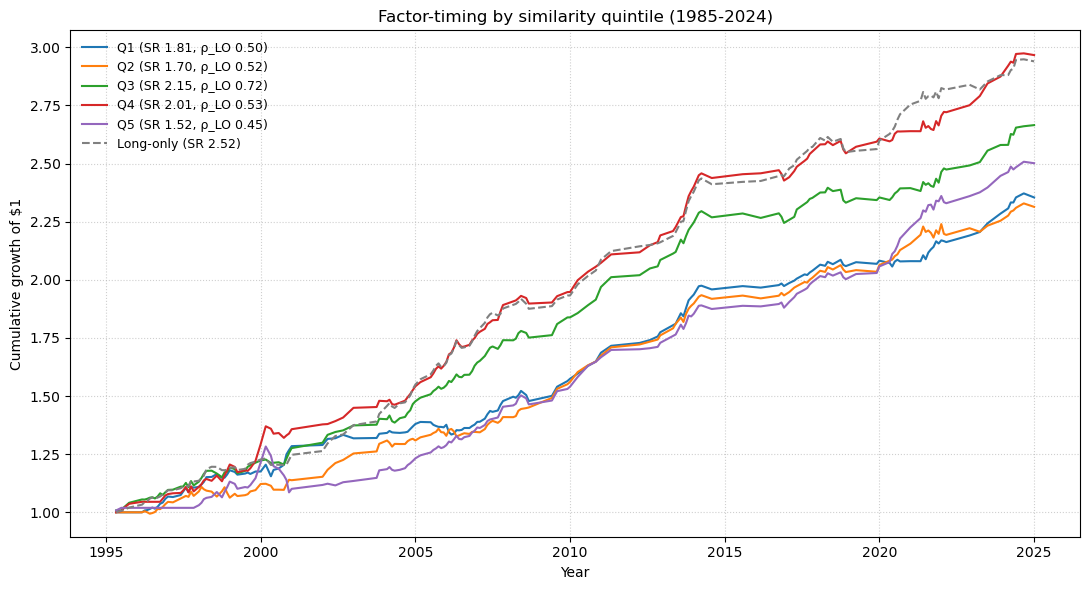

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

lookback_gap  = 36                             
factors       = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
colors        = {1:"tab:blue", 2:"tab:orange", 3:"tab:green",
                 4:"tab:red", 5:"tab:purple"}

BACKTEST_START = pd.Period('1995-01', freq='M')
BACKTEST_END   = pd.Period('2024-12', freq='M')

def quintile_members(df_period: pd.DataFrame, target_per: pd.Period):
    """
    Return dict{1…5 → ndarray of months} following the paper’s rules:
      • Q1 = closest 20 %
      • Q5 = farthest 20 %
      • Q2-Q4 = equal thirds of the middle 60 %
    """
    full = find_similar_months(
        df_period      = df_period,
        target         = str(target_per),
        exclude_last_n = lookback_gap,
        bottom_pct     = 1.0             
    ).sort_values("Distance")            

    n = len(full)
    if n == 0:                          
        return {q: np.array([]) for q in range(1, 6)}

    k20 = int(0.20 * n)
    q1  = full.iloc[:k20]['Month'].to_numpy()
    q5  = full.iloc[-k20:]['Month'].to_numpy()

    mid = full.iloc[k20:-k20]['Month'].to_numpy()
    q2, q3, q4 = np.array_split(mid, 3)

    return {1: q1, 2: q2, 3: q3, 4: q4, 5: q5}

def signal_for_quintile(df_period, target_per, quintile):
    months = quintile_members(df_period, target_per)[quintile]
    if len(months) == 0:
        return {f: 0 for f in factors}

    idx = pd.PeriodIndex(months, freq="M") + 1         
    signs = {}
    for f in factors:
        rets = concat_fff.loc[concat_fff.index.intersection(idx), f]
        signs[f] = np.sign(rets.mean()) if not rets.empty else 0
    return signs

first_possible = df_period.index.min() + (lookback_gap + 1)
hist_start     = max(BACKTEST_START, first_possible)
hist_end       = min(BACKTEST_END,   concat_fff.index.max())

all_months = concat_fff.index.sort_values()
start_idx  = next(i for i, per in enumerate(all_months) if per >= hist_start)
stop_idx   = next(i for i, per in enumerate(all_months) if per >  hist_end) - 1

returns_by_q = {q: [] for q in range(1, 6)}

for i in range(start_idx, stop_idx):
    cur_per = all_months[i]
    nxt_per = all_months[i + 1]
    r       = concat_fff.loc[nxt_per, factors]

    for q in range(1, 6):
        sig = signal_for_quintile(df_period, cur_per, q)
        ret = np.mean([sig[f] * r[f] for f in factors])
        returns_by_q[q].append({"Date": nxt_per, "Return": ret})

q_df = {q: pd.DataFrame(lst).set_index("Date") for q, lst in returns_by_q.items()}

long_only = concat_fff[factors].mean(axis=1).loc[q_df[1].index]

ann_sr  = lambda x: (x.mean() / x.std()) * np.sqrt(12) if x.std() != 0 else np.nan
corr_lo = lambda x: x.corr(long_only)

stats = {q: (ann_sr(df["Return"]), corr_lo(df["Return"])) for q, df in q_df.items()}
sr_lo = ann_sr(long_only)

cum = lambda x: (1 + x).cumprod()

plt.figure(figsize=(11, 6))
for q in range(1, 6):
    plt.plot(q_df[q].index.to_timestamp(how="end"),
             cum(q_df[q]["Return"]),
             color=colors[q],
             label=f"Q{q} (SR {stats[q][0]:.2f}, ρ_LO {stats[q][1]:.2f})")

plt.plot(q_df[1].index.to_timestamp(how="end"),
         cum(long_only), color="gray", ls="--",
         label=f"Long-only (SR {sr_lo:.2f})")

plt.title("Factor-timing by similarity quintile (1985-2024)")
plt.xlabel("Year")
plt.ylabel("Cumulative growth of $1")
plt.legend(frameon=False, fontsize=9)
plt.grid(ls=":", alpha=.6)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


In [46]:
import numpy as np
import pandas as pd

def find_similar_months(
    df_period: pd.DataFrame,
    target: str,
    exclude_last_n: int = 36,
    bottom_pct: float = 0.15
) -> pd.DataFrame:
    """
    Cosine distance to target row:
      dist(x, y) = 1 - (x·y)/(||x|| ||y||)
    Smaller = more similar.
    """
    eps = 1e-12
    T_period = pd.Period(target, freq="M")

    # Exclude recent months
    cutoff_period = T_period - exclude_last_n
    df_candidates = df_period.loc[df_period.index <= cutoff_period].dropna(how="any").copy()
    if df_candidates.empty:
        return pd.DataFrame({'Month': [], 'Distance': [], 'Rank': [], 'IsBottom': []})

    # Target vector
    z_T = df_period.loc[T_period].to_numpy(dtype=float, copy=True)
    if np.isnan(z_T).any():
        return pd.DataFrame({'Month': [], 'Distance': [], 'Rank': [], 'IsBottom': []})
    z_norm = np.linalg.norm(z_T)
    if z_norm < eps:
        raise ValueError("Target vector has near-zero norm; cosine distance is undefined.")

    # Candidate matrix
    mat = df_candidates.to_numpy(dtype=float, copy=True)
    mat_norms = np.linalg.norm(mat, axis=1)

    # Drop zero-norm candidates
    keep = mat_norms > eps
    if not np.any(keep):
        return pd.DataFrame({'Month': [], 'Distance': [], 'Rank': [], 'IsBottom': []})
    mat = mat[keep]
    mat_norms = mat_norms[keep]
    kept_index = df_candidates.index[keep]

    # Cosine similarity and distance
    denom = np.maximum(mat_norms * z_norm, eps)
    sims = (mat @ z_T) / denom
    sims = np.clip(sims, -1.0, 1.0)   # numerical safety
    dist = 1.0 - sims                 # in [0, 2]

    out = pd.DataFrame({'Month': kept_index, 'Distance': dist})
    out = out.sort_values('Distance', ascending=True).reset_index(drop=True)
    out['Rank'] = np.arange(1, len(out) + 1)

    n_select = max(int(np.floor(bottom_pct * len(out))), 1)
    out['IsBottom'] = False
    out.loc[:n_select - 1, 'IsBottom'] = True
    return out



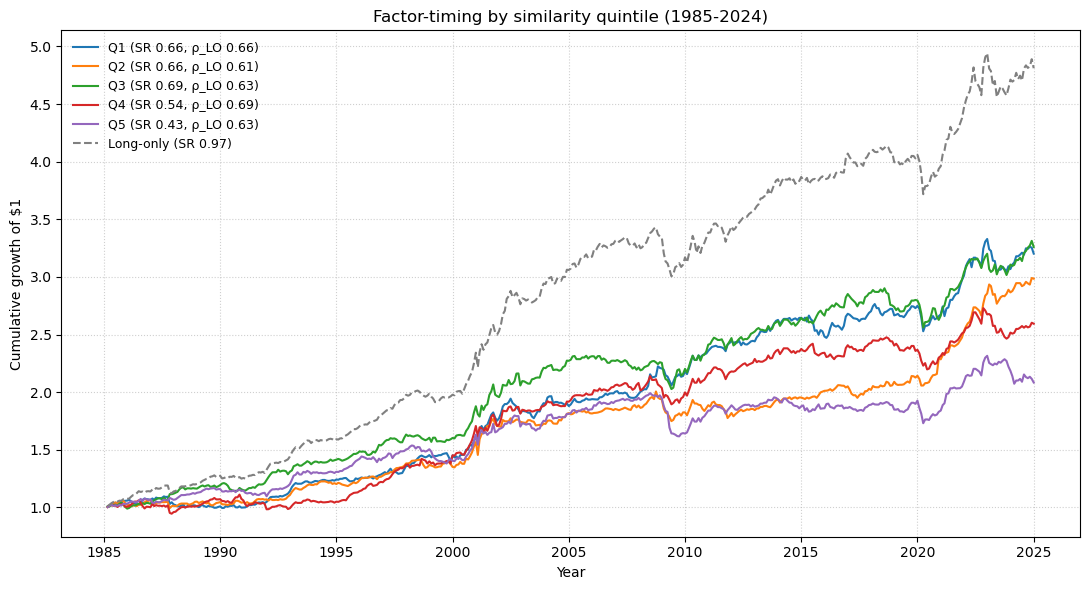

In [47]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

lookback_gap  = 36                             
factors       = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
colors        = {1:"tab:blue", 2:"tab:orange", 3:"tab:green",
                 4:"tab:red", 5:"tab:purple"}

BACKTEST_START = pd.Period('1985-01', freq='M')
BACKTEST_END   = pd.Period('2024-12', freq='M')

def quintile_members(df_period: pd.DataFrame, target_per: pd.Period):
    """
    Return dict{1…5 → ndarray of months} following the paper’s rules:
      • Q1 = closest 20 %
      • Q5 = farthest 20 %
      • Q2-Q4 = equal thirds of the middle 60 %
    """
    full = find_similar_months(
        df_period      = df_period,
        target         = str(target_per),
        exclude_last_n = lookback_gap,
        bottom_pct     = 1.0             
    ).sort_values("Distance")            

    n = len(full)
    if n == 0:                          
        return {q: np.array([]) for q in range(1, 6)}

    k20 = int(0.20 * n)
    q1  = full.iloc[:k20]['Month'].to_numpy()
    q5  = full.iloc[-k20:]['Month'].to_numpy()

    mid = full.iloc[k20:-k20]['Month'].to_numpy()
    q2, q3, q4 = np.array_split(mid, 3)

    return {1: q1, 2: q2, 3: q3, 4: q4, 5: q5}

def signal_for_quintile(df_period, target_per, quintile):
    months = quintile_members(df_period, target_per)[quintile]
    if len(months) == 0:
        return {f: 0 for f in factors}

    idx = pd.PeriodIndex(months, freq="M") + 1         
    signs = {}
    for f in factors:
        rets = concat_fff.loc[concat_fff.index.intersection(idx), f]
        signs[f] = np.sign(rets.mean()) if not rets.empty else 0
    return signs

first_possible = df_period.index.min() + (lookback_gap + 1)
hist_start     = max(BACKTEST_START, first_possible)
hist_end       = min(BACKTEST_END,   concat_fff.index.max())

all_months = concat_fff.index.sort_values()
start_idx  = next(i for i, per in enumerate(all_months) if per >= hist_start)
stop_idx   = next(i for i, per in enumerate(all_months) if per >  hist_end) - 1

returns_by_q = {q: [] for q in range(1, 6)}

for i in range(start_idx, stop_idx):
    cur_per = all_months[i]
    nxt_per = all_months[i + 1]
    r       = concat_fff.loc[nxt_per, factors]

    for q in range(1, 6):
        sig = signal_for_quintile(df_period, cur_per, q)
        ret = np.mean([sig[f] * r[f] for f in factors])
        returns_by_q[q].append({"Date": nxt_per, "Return": ret})

q_df = {q: pd.DataFrame(lst).set_index("Date") for q, lst in returns_by_q.items()}

long_only = concat_fff[factors].mean(axis=1).loc[q_df[1].index]

ann_sr  = lambda x: (x.mean() / x.std()) * np.sqrt(12) if x.std() != 0 else np.nan
corr_lo = lambda x: x.corr(long_only)

stats = {q: (ann_sr(df["Return"]), corr_lo(df["Return"])) for q, df in q_df.items()}
sr_lo = ann_sr(long_only)

cum = lambda x: (1 + x).cumprod()

plt.figure(figsize=(11, 6))
for q in range(1, 6):
    plt.plot(q_df[q].index.to_timestamp(how="end"),
             cum(q_df[q]["Return"]),
             color=colors[q],
             label=f"Q{q} (SR {stats[q][0]:.2f}, ρ_LO {stats[q][1]:.2f})")

plt.plot(q_df[1].index.to_timestamp(how="end"),
         cum(long_only), color="gray", ls="--",
         label=f"Long-only (SR {sr_lo:.2f})")

plt.title("Factor-timing by similarity quintile (1985-2024)")
plt.xlabel("Year")
plt.ylabel("Cumulative growth of $1")
plt.legend(frameon=False, fontsize=9)
plt.grid(ls=":", alpha=.6)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

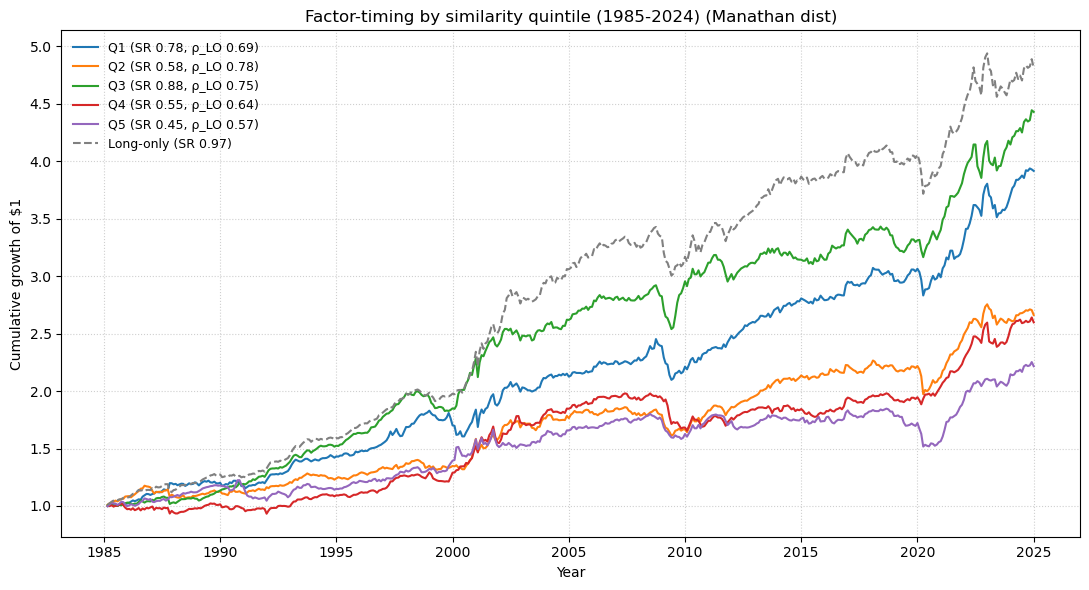

In [48]:
import numpy as np
import pandas as pd

def find_similar_months_manhattan(
    df_period: pd.DataFrame,
    target: str,
    exclude_last_n: int = 36,
    bottom_pct: float = 0.15
) -> pd.DataFrame:
    """
    Manhattan (L1) distance to target row:
        dist(x, y) = sum_i |x_i - y_i|
    Smaller = more similar.
    Returns columns: Month, Distance, Rank, IsBottom
    """
    # Target month as Period
    T_period = pd.Period(target, freq="M")
    if T_period not in df_period.index:
        raise KeyError(f"Target month {T_period} not found in df_period.index")

    # Exclude recent months to avoid overlap bias
    cutoff_period = T_period - exclude_last_n
    df_candidates = df_period.loc[df_period.index <= cutoff_period].dropna(how="any").copy()
    if df_candidates.empty:
        return pd.DataFrame({'Month': [], 'Distance': [], 'Rank': [], 'IsBottom': []})

    # Target vector (ensure no NaNs)
    z_T = df_period.loc[T_period].to_numpy(dtype=float, copy=True)
    if np.isnan(z_T).any():
        return pd.DataFrame({'Month': [], 'Distance': [], 'Rank': [], 'IsBottom': []})

    # Candidate matrix
    mat = df_candidates.to_numpy(dtype=float, copy=True)

    # Manhattan/L1 distance (vectorized)
    dists = np.abs(mat - z_T).sum(axis=1)

    # Build output
    out = pd.DataFrame({'Month': df_candidates.index, 'Distance': dists})
    out = out.sort_values('Distance', ascending=True).reset_index(drop=True)
    out['Rank'] = np.arange(1, len(out) + 1)

    n_select = max(int(np.floor(bottom_pct * len(out))), 1)
    out['IsBottom'] = False
    out.loc[:n_select - 1, 'IsBottom'] = True
    return out

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

lookback_gap  = 36                             
factors       = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
colors        = {1:"tab:blue", 2:"tab:orange", 3:"tab:green",
                 4:"tab:red", 5:"tab:purple"}

BACKTEST_START = pd.Period('1985-01', freq='M')
BACKTEST_END   = pd.Period('2024-12', freq='M')

def quintile_members(df_period: pd.DataFrame, target_per: pd.Period):
    """
    Return dict{1…5 → ndarray of months} following the paper’s rules:
      • Q1 = closest 20 %
      • Q5 = farthest 20 %
      • Q2-Q4 = equal thirds of the middle 60 %
    """
    full = find_similar_months_manhattan(
        df_period      = df_period,
        target         = str(target_per),
        exclude_last_n = lookback_gap,
        bottom_pct     = 1.0             
    ).sort_values("Distance")            

    n = len(full)
    if n == 0:                          
        return {q: np.array([]) for q in range(1, 6)}

    k20 = int(0.20 * n)
    q1  = full.iloc[:k20]['Month'].to_numpy()
    q5  = full.iloc[-k20:]['Month'].to_numpy()

    mid = full.iloc[k20:-k20]['Month'].to_numpy()
    q2, q3, q4 = np.array_split(mid, 3)

    return {1: q1, 2: q2, 3: q3, 4: q4, 5: q5}

def signal_for_quintile(df_period, target_per, quintile):
    months = quintile_members(df_period, target_per)[quintile]
    if len(months) == 0:
        return {f: 0 for f in factors}

    idx = pd.PeriodIndex(months, freq="M") + 1         
    signs = {}
    for f in factors:
        rets = concat_fff.loc[concat_fff.index.intersection(idx), f]
        signs[f] = np.sign(rets.mean()) if not rets.empty else 0
    return signs

first_possible = df_period.index.min() + (lookback_gap + 1)
hist_start     = max(BACKTEST_START, first_possible)
hist_end       = min(BACKTEST_END,   concat_fff.index.max())

all_months = concat_fff.index.sort_values()
start_idx  = next(i for i, per in enumerate(all_months) if per >= hist_start)
stop_idx   = next(i for i, per in enumerate(all_months) if per >  hist_end) - 1

returns_by_q = {q: [] for q in range(1, 6)}

for i in range(start_idx, stop_idx):
    cur_per = all_months[i]
    nxt_per = all_months[i + 1]
    r       = concat_fff.loc[nxt_per, factors]

    for q in range(1, 6):
        sig = signal_for_quintile(df_period, cur_per, q)
        ret = np.mean([sig[f] * r[f] for f in factors])
        returns_by_q[q].append({"Date": nxt_per, "Return": ret})

q_df = {q: pd.DataFrame(lst).set_index("Date") for q, lst in returns_by_q.items()}

long_only = concat_fff[factors].mean(axis=1).loc[q_df[1].index]

ann_sr  = lambda x: (x.mean() / x.std()) * np.sqrt(12) if x.std() != 0 else np.nan
corr_lo = lambda x: x.corr(long_only)

stats = {q: (ann_sr(df["Return"]), corr_lo(df["Return"])) for q, df in q_df.items()}
sr_lo = ann_sr(long_only)

cum = lambda x: (1 + x).cumprod()

plt.figure(figsize=(11, 6))
for q in range(1, 6):
    plt.plot(q_df[q].index.to_timestamp(how="end"),
             cum(q_df[q]["Return"]),
             color=colors[q],
             label=f"Q{q} (SR {stats[q][0]:.2f}, ρ_LO {stats[q][1]:.2f})")

plt.plot(q_df[1].index.to_timestamp(how="end"),
         cum(long_only), color="gray", ls="--",
         label=f"Long-only (SR {sr_lo:.2f})")

plt.title("Factor-timing by similarity quintile (1985-2024) (Manathan dist)")
plt.xlabel("Year")
plt.ylabel("Cumulative growth of $1")
plt.legend(frameon=False, fontsize=9)
plt.grid(ls=":", alpha=.6)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

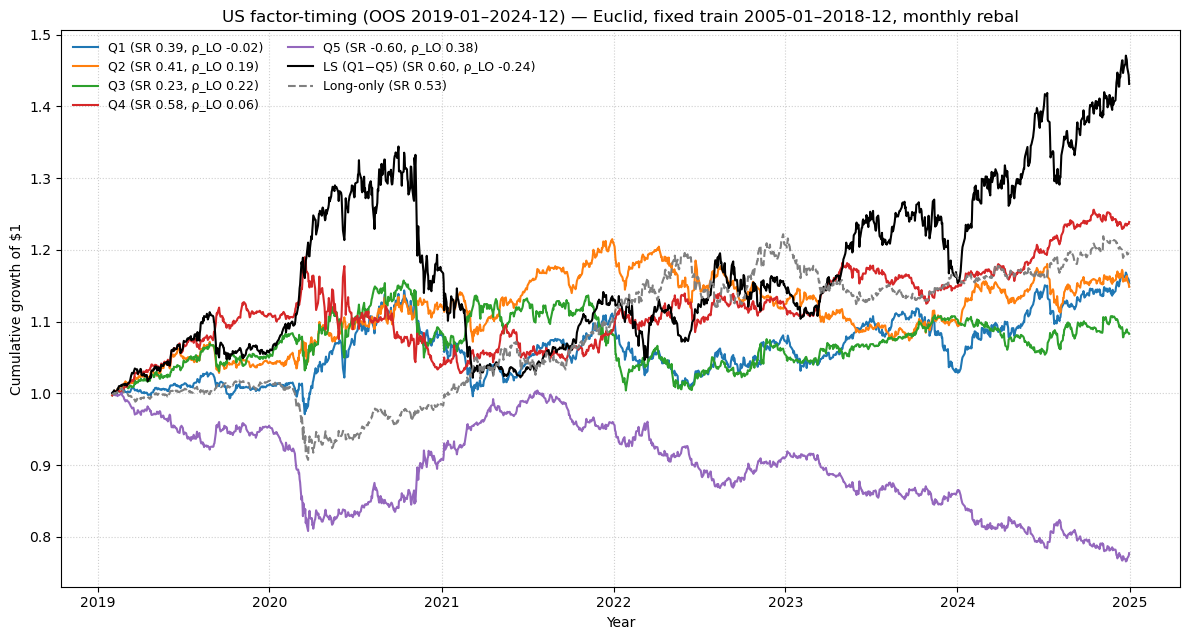

            Ann. Return  Ann. Vol  Ann. Sharpe  Corr vs LO  Max DD  N days
Q1               0.0246    0.0686       0.3883     -0.0154 -0.1290  1489.0
Q2               0.0237    0.0620       0.4085      0.1916 -0.1164  1489.0
Q3               0.0136    0.0673       0.2342      0.2154 -0.1324  1489.0
Q4               0.0369    0.0663       0.5797      0.0616 -0.1358  1489.0
Q5              -0.0417    0.0677      -0.5963      0.3787 -0.2373  1489.0
LS (Q1−Q5)       0.0626    0.1121       0.5978     -0.2381 -0.2397  1489.0
Long-only        0.0306    0.0604       0.5283      1.0000 -0.1087  1489.0


In [70]:
# ============================================
# US: Daily-traded factor timing (fixed-train → OOS)
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from typing import Union

# ----------------------------
# Config
# ----------------------------
REBALANCING = 'monthly'   # 'monthly' or 'daily'
TRAIN_START, TRAIN_END = pd.Period('2005-01','M'), pd.Period('2018-12','M')
OOS_START,   OOS_END   = pd.Period('2019-01','M'), pd.Period('2024-12','M')

# ----------------------------
# 1) Use your macro panel (df_period) exactly as built above
#    df_period has 'Month' + 7 z-score columns
# ----------------------------
# Ensure PeriodIndex('M')
if 'Month' in df_period.columns:
    df_m = df_period.copy()
    df_m['Month'] = pd.PeriodIndex(df_m['Month'], freq='M')
    df_m = df_m.set_index('Month').sort_index()
else:
    df_m = df_period.copy()
    if not isinstance(df_m.index, pd.PeriodIndex):
        df_m.index = pd.to_datetime(df_m.index, errors='coerce').to_period('M')
    df_m = df_m.sort_index()

# Ensure numeric columns only
df_m = df_m.select_dtypes(include=[np.number]).dropna(how='all')

# ----------------------------
# 2) Load US DAILY FF factors (5×2×3 + Momentum daily)
# ----------------------------
ff_5f  = (pd.read_csv(r"C:\Users\kelvi\Downloads\F-F_Research_Data_5_Factors_2x3_daily_CSV\F-F_Research_Data_5_Factors_2x3_daily.csv",
                       engine="python")
           .rename(columns={"Unnamed: 0": "Dates"}))
ff_mom = (pd.read_csv(r"C:\Users\kelvi\Downloads\F-F_Momentum_Factor_daily_CSV\F-F_Momentum_Factor_daily.csv",
                       engine="python")
           .rename(columns={"Unnamed: 0": "Dates"}))

# Parse dates and convert to decimals
for df in (ff_5f, ff_mom):
    df["Dates"] = pd.to_datetime(df["Dates"].astype(str), format="%Y%m%d", errors="coerce")
    for c in df.columns:
        if c != "Dates":
            df[c] = pd.to_numeric(df[c], errors="coerce") / 100.0

# Merge
factors_raw = (ff_5f.merge(ff_mom, on="Dates", how="outer")
                        .dropna(subset=["Dates"])
                        .sort_values("Dates")
                        .reset_index(drop=True))

# Resolve momentum column name to 'Mom'
mom_candidates = [c for c in factors_raw.columns if c.strip().lower() in ("mom","wml","umd")]
if not mom_candidates:
    raise ValueError("Could not find momentum column in the daily momentum CSV (looked for Mom/WML/UMD).")
mom_col = mom_candidates[0]
if mom_col != 'Mom':
    factors_raw = factors_raw.rename(columns={mom_col: 'Mom'})

# Keep only the six factor columns (exclude RF)
FACTOR_LIST = ['Mkt-RF','SMB','HML','RMW','CMA','Mom']
present = [c for c in FACTOR_LIST if c in factors_raw.columns]
missing = [c for c in FACTOR_LIST if c not in present]
if missing:
    raise ValueError(f"Missing factor columns in US daily file: {missing}")
factors = factors_raw[['Dates'] + present].copy()

# Daily factor returns
fac_ret_daily = (factors
                 .dropna(subset=['Dates'])
                 .set_index('Dates')
                 [present]
                 .astype(float)
                 .replace([np.inf,-np.inf], np.nan)
                 .dropna(how='all'))

# Monthly comp for signal estimation
fac_ret_monthly = (1.0 + fac_ret_daily).resample("ME").prod().sub(1.0)
fac_ret_monthly.index = fac_ret_monthly.index.to_period("M")
factor_months = fac_ret_monthly.index.sort_values()

# ----------------------------
# 3) Train/OOS windows on your macro panel
# ----------------------------
df_train = df_m.loc[(df_m.index >= TRAIN_START) & (df_m.index <= TRAIN_END)]
if df_train.dropna(how='any').empty:
    raise ValueError("Training window has no fully non-NaN rows in df_train (2005–2018).")

oos_stop  = min(OOS_END, factor_months.max())
months_bt = factor_months[(factor_months >= OOS_START) & (factor_months <= oos_stop)]
if len(months_bt) < 2:
    raise ValueError("No OOS months to backtest with daily execution.")

# ----------------------------
# 4) Similarity search (fixed training set, Euclidean)
# ----------------------------
def _ensure_period_m_index(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if isinstance(out.index, pd.PeriodIndex):
        out.index = out.index.asfreq('M')
    elif isinstance(out.index, pd.DatetimeIndex):
        out.index = out.index.to_period('M')
    else:
        out.index = pd.to_datetime(out.index, errors='coerce').to_period('M')
    return out.sort_index()

def find_similar_months_euclid_fixed_train(
    df_full: pd.DataFrame, df_train: pd.DataFrame,
    target: Union[str, pd.Period, pd.Timestamp],
    bottom_pct: float = 1.0, require_complete_rows: bool = True
) -> pd.DataFrame:
    df_full  = _ensure_period_m_index(df_full)
    df_train = _ensure_period_m_index(df_train)

    cols = df_full.columns.intersection(df_train.columns)
    if len(cols) == 0:
        return pd.DataFrame(columns=['Month','Distance','Rank','IsBottom'])
    X_full, X_train = df_full[cols], df_train[cols]

    if isinstance(target, pd.Period):
        T = target.asfreq('M')
    elif isinstance(target, pd.Timestamp):
        T = target.to_period('M')
    else:
        T = pd.Period(str(target), freq='M')
    if T not in X_full.index:
        prior = X_full.index[X_full.index < T]
        if len(prior) == 0:
            return pd.DataFrame(columns=['Month','Distance','Rank','IsBottom'])
        T = prior.max()

    C = X_train.dropna(how='any') if require_complete_rows else X_train.copy()
    if C.empty:
        return pd.DataFrame(columns=['Month','Distance','Rank','IsBottom'])

    x_T  = X_full.loc[T].to_numpy(dtype=float).reshape(1,-1)
    X    = C.to_numpy(dtype=float)
    dist = np.linalg.norm(X - x_T, axis=1)

    out = pd.DataFrame({'Distance': dist}, index=C.index).sort_values('Distance')
    out['Rank'] = np.arange(1, len(out) + 1)
    n_select = max(int(np.floor(bottom_pct * len(out))), 1)
    isbottom = np.zeros(len(out), dtype=bool); isbottom[:n_select] = True
    out['IsBottom'] = isbottom
    out.index.name = 'Month'
    return out.reset_index()

def quintile_members_euclid_fixed(target_per: pd.Period):
    full = find_similar_months_euclid_fixed_train(df_m, df_train, target_per).sort_values('Distance')
    if full.empty:
        return {q: np.array([]) for q in range(1,6)}
    n = len(full); k20 = int(0.20*n)
    if k20 == 0:
        return {1: np.array([]), 2: np.array([]), 3: full['Month'].to_numpy(), 4: np.array([]), 5: np.array([])}
    q1  = full.iloc[:k20]['Month'].to_numpy()
    q5  = full.iloc[-k20:]['Month'].to_numpy()
    mid = full.iloc[k20:-k20]['Month'].to_numpy()
    if len(mid) >= 3: q2,q3,q4 = np.array_split(mid, 3)
    else:             q2,q3,q4 = np.array([]), mid, np.array([])
    return {1:q1,2:q2,3:q3,4:q4,5:q5}

def signal_for_quintile_euclid_fixed(target_per: pd.Period, quintile: int):
    months = quintile_members_euclid_fixed(target_per)[quintile]
    if len(months) == 0:
        return {a: 0 for a in FACTOR_LIST}
    idx = pd.PeriodIndex(months, freq='M') + 1  # next-month returns
    signs = {}
    for a in FACTOR_LIST:
        r = fac_ret_monthly.loc[fac_ret_monthly.index.intersection(idx), a]
        signs[a] = np.sign(r.mean()) if not r.empty else 0
    return signs

# ----------------------------
# 5) Execution helper (constant gross = 1)
# ----------------------------
def days_in_period(idx_daily: pd.DatetimeIndex, per: pd.Period):
    return idx_daily[idx_daily.to_period('M') == per]

def compute_daily_returns_for_month(Rm_active: pd.DataFrame, w: pd.Series, rebalancing: str) -> pd.Series:
    if rebalancing == 'monthly':
        def day_ret(row):
            present_r = row.dropna()
            if present_r.empty: return 0.0
            w_sub = w.reindex(present_r.index).dropna()
            if w_sub.empty: return 0.0
            w_sub = w_sub / w_sub.abs().sum()
            return float((present_r * w_sub).sum())
        return Rm_active.apply(day_ret, axis=1)
    elif rebalancing == 'daily':
        def day_ret(row):
            present_r = row.dropna()
            if present_r.empty: return 0.0
            tgt = w.reindex(present_r.index).dropna()
            if tgt.empty: return 0.0
            tgt = tgt / tgt.abs().sum()
            return float((present_r * tgt).sum())
        return Rm_active.apply(day_ret, axis=1)
    else:
        raise ValueError("REBALANCING must be 'monthly' or 'daily'.")

# ----------------------------
# 6) Daily OOS backtest (US)
# ----------------------------
returns_by_q = {q: [] for q in range(1,6)}

for i in range(len(months_bt)-1):
    cur_per, nxt_per = months_bt[i], months_bt[i+1]
    dts = days_in_period(fac_ret_daily.index, nxt_per)
    if len(dts) == 0:
        continue
    Rm = fac_ret_daily.loc[dts, FACTOR_LIST].astype(float)

    for q in range(1,6):
        sigs = signal_for_quintile_euclid_fixed(cur_per, q)
        active = [a for a in FACTOR_LIST if sigs.get(a, 0) != 0]
        if not active:
            returns_by_q[q].extend([{'Date': dt, 'Return': 0.0} for dt in dts])
            continue
        Rm_active = Rm[active]
        w = pd.Series({a: sigs[a] for a in active}, dtype=float)
        w = w / w.abs().sum()  # unit gross
        port_daily = compute_daily_returns_for_month(Rm_active, w, REBALANCING)
        returns_by_q[q].extend([{'Date': dt, 'Return': float(ret)} for dt, ret in port_daily.items()])

# Pack into frames & align start
q_df = {q: pd.DataFrame(lst).set_index('Date').sort_index() for q, lst in returns_by_q.items()}
common_idx = None
for q in range(1,6):
    idx = q_df[q].index
    common_idx = idx if common_idx is None else common_idx.intersection(idx)
first_trd = common_idx.min()
for q in q_df:
    q_df[q] = q_df[q].loc[first_trd:]

# Long-only (US): equal-weight across the 6 factors
long_only = fac_ret_daily[FACTOR_LIST].mean(axis=1).loc[first_trd:].reindex(q_df[1].index).dropna()

# ----------------------------
# 7) Metrics & Plot (US)
# ----------------------------
def ann_sr(x):
    s = x.std()
    return (x.mean()/s)*np.sqrt(252) if s and s!=0 else np.nan
def ann_ret(x):
    n = len(x);  return (1 + x).prod()**(252.0/n) - 1 if n > 0 else np.nan
def ann_vol(x): return x.std()*np.sqrt(252)
def max_dd(x):
    eq = (1+x).cumprod()
    return (eq/eq.cummax() - 1.0).min()

ports = {
    'Q1': q_df[1]['Return'].astype(float),
    'Q2': q_df[2]['Return'].astype(float),
    'Q3': q_df[3]['Return'].astype(float),
    'Q4': q_df[4]['Return'].astype(float),
    'Q5': q_df[5]['Return'].astype(float),
    'Long-only': long_only.astype(float)
}
ls_tmp = pd.concat([ports['Q1'], ports['Q5']], axis=1).dropna()
ports['LS (Q1−Q5)'] = (ls_tmp.iloc[:,0] - ls_tmp.iloc[:,1]).rename('LS (Q1−Q5)')

# Align for stats
common_idx_all = None
for s in ports.values():
    common_idx_all = s.index if common_idx_all is None else common_idx_all.intersection(s.index)
ports = {k: v.loc[common_idx_all] for k,v in ports.items()}

# Table
rows = {}
lo_aligned = ports['Long-only']
for name, s in ports.items():
    rows[name] = {
        'Ann. Return': ann_ret(s),
        'Ann. Vol':    ann_vol(s),
        'Ann. Sharpe': ann_sr(s),
        'Corr vs LO':  s.corr(lo_aligned),
        'Max DD':      max_dd(s),
        'N days':      int(len(s)),
    }
order = ['Q1','Q2','Q3','Q4','Q5','LS (Q1−Q5)','Long-only']
summary_df = pd.DataFrame(rows).T.reindex(order)

# Plot
cum = lambda x: (1+x).cumprod()
plt.figure(figsize=(12, 6.5))
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
for q, col in zip([1,2,3,4,5], colors):
    s  = ports[f'Q{q}']
    sr = summary_df.loc[f'Q{q}', 'Ann. Sharpe']
    rho= summary_df.loc[f'Q{q}', 'Corr vs LO']
    plt.plot(s.index, cum(s), label=f"Q{q} (SR {sr:.2f}, ρ_LO {rho:.2f})", color=col)

sr_ls  = summary_df.loc['LS (Q1−Q5)', 'Ann. Sharpe']
rho_ls = summary_df.loc['LS (Q1−Q5)', 'Corr vs LO']
plt.plot(ports['LS (Q1−Q5)'].index, cum(ports['LS (Q1−Q5)']),
         label=f"LS (Q1−Q5) (SR {sr_ls:.2f}, ρ_LO {rho_ls:.2f})", color='black')

sr_lo = summary_df.loc['Long-only', 'Ann. Sharpe']
plt.plot(ports['Long-only'].index, cum(ports['Long-only']), ls='--',
         label=f"Long-only (SR {sr_lo:.2f})", color='gray')

plt.title(f"US factor-timing (OOS {OOS_START}–{OOS_END}) — Euclid, fixed train {TRAIN_START}–{TRAIN_END}, {REBALANCING} rebal")
plt.xlabel("Year"); plt.ylabel("Cumulative growth of $1")
plt.grid(ls=":", alpha=.6)
ax = plt.gca()
ax.legend(frameon=False, fontsize=9, ncols=2)
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print(summary_df.round(4))


Daily rows: 15625 | range: 1963-07-01 00:00:00 → 2025-07-31 00:00:00


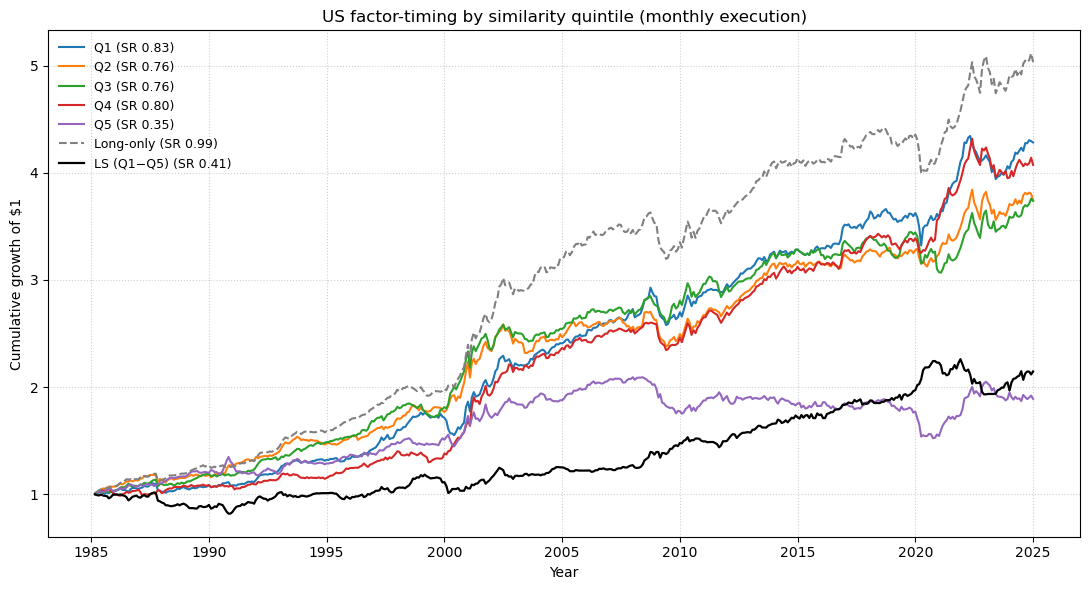

In [104]:
# ============================
# Monthly backtest from US daily FF files
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

FACTOR_LIST = ['Mkt-RF','SMB','HML','RMW','CMA','Mom']  # exclude RF
LOOKBACK_GAP = 36
BACKTEST_START = pd.Period('1985-01','M')
BACKTEST_END   = pd.Period('2024-12','M')

# 1) Parse daily files you defined (ff_5f, ff_mom)
for df in (ff_5f, ff_mom):
    df['Dates'] = pd.to_datetime(df['Dates'].astype(str), format='%Y%m%d', errors='coerce')
    for c in df.columns:
        if c != 'Dates':
            df[c] = pd.to_numeric(df[c], errors='coerce')/100.0
import numpy as np
import pandas as pd

FACTOR_LIST = ['Mkt-RF','SMB','HML','RMW','CMA','Mom']

# --- 1) Read raw daily files (US) ---
ff_5f  = pd.read_csv(
    r"C:\Users\kelvi\Downloads\F-F_Research_Data_5_Factors_2x3_daily_CSV\F-F_Research_Data_5_Factors_2x3_daily.csv",
    engine="python"
).rename(columns={"Unnamed: 0": "Dates"})

ff_mom = pd.read_csv(
    r"C:\Users\kelvi\Downloads\F-F_Momentum_Factor_daily_CSV\F-F_Momentum_Factor_daily.csv",
    engine="python"
).rename(columns={"Unnamed: 0": "Dates"})

# --- 2) Keep only rows that look like YYYYMMDD, then parse to datetime ---
def clean_daily(df, want_cols):
    # extract strictly 8 digits (handles "19630701.0", spaces, etc.)
    date8 = df['Dates'].astype(str).str.extract(r'(\d{8})', expand=False)
    df = df.loc[date8.notna()].copy()
    df['Dates'] = pd.to_datetime(date8, format='%Y%m%d', errors='coerce')
    df = df.loc[df['Dates'].notna()]
    # keep only requested columns that exist
    keep = ['Dates'] + [c for c in want_cols if c in df.columns]
    df = df[keep]
    # numeric -> decimal returns; downcast to float32 to save RAM
    for c in df.columns:
        if c != 'Dates':
            df[c] = pd.to_numeric(df[c], errors='coerce') / 100.0
            df[c] = df[c].astype('float32')
    # drop exact duplicate rows and duplicate dates
    df = df.drop_duplicates()
    df = df.sort_values('Dates')
    dup_ct = df['Dates'].duplicated().sum()
    if dup_ct:
        # If duplicates remain on the same date, average them (safer than dropping first)
        df = df.groupby('Dates', as_index=False).mean(numeric_only=True)
    return df

ff_5f = clean_daily(ff_5f, ['Mkt-RF','SMB','HML','RMW','CMA','RF'])
ff_mom = clean_daily(ff_mom, ['Mom','WML'])  # some files use WML naming

# Standardize momentum name to 'Mom'
if 'Mom' not in ff_mom.columns and 'WML' in ff_mom.columns:
    ff_mom = ff_mom.rename(columns={'WML': 'Mom'})

# --- 3) Make Dates unique and join one-to-one on index ---
ff_5f = ff_5f.set_index('Dates').sort_index()
ff_mom = ff_mom.set_index('Dates').sort_index()

# sanity checks before joining
assert not ff_5f.index.has_duplicates, "5F still has duplicate Dates after cleaning."
assert not ff_mom.index.has_duplicates, "MOM still has duplicate Dates after cleaning."

# inner join on the (unique) Dates index
factors_daily = ff_5f.join(ff_mom[['Mom']], how='inner')
# optional: ensure only the six columns we need
present = [c for c in FACTOR_LIST if c in factors_daily.columns]
factors_daily = factors_daily[present + (['RF'] if 'RF' in factors_daily.columns else [])]

print("Daily rows:", len(factors_daily), "| range:", factors_daily.index.min(), "→", factors_daily.index.max())

# --- 4) Daily → Monthly compounding (month-end), PeriodIndex('M') ---
factors_monthly = (1.0 + factors_daily).resample('ME').prod().sub(1.0)
factors_monthly.index = factors_monthly.index.to_period('M')

# If you want to keep RF separate:
if 'RF' in factors_monthly.columns:
    rf = factors_monthly.pop('RF')  # still available in `rf` if needed later

# Now `factors_monthly` has Mkt-RF, SMB, HML, RMW, CMA, Mom — monthly decimals on Period[M].


# 3) Macro z-panel (df_period with 'Month' column)
Z = df_period.copy()
if 'Month' in Z.columns:
    Z['Month'] = pd.PeriodIndex(Z['Month'], freq='M')
    Z = Z.set_index('Month')
else:
    if not isinstance(Z.index, pd.PeriodIndex):
        Z.index = pd.to_datetime(Z.index, errors='coerce').to_period('M')
Z = Z.sort_index()
# numeric only, align & ffill
num_cols = [c for c in Z.columns if pd.api.types.is_numeric_dtype(Z[c])]
Z = Z[num_cols]
Z = Z.reindex(pd.period_range(Z.index.min(), Z.index.max(), freq='M')).ffill()
Z = Z.reindex(factors_monthly.index).ffill()

# 4) Similarity helpers (expanding with gap)
def find_similar_months(df_period: pd.DataFrame, target, exclude_last_n=36, bottom_pct=1.0):
    T = pd.Period(str(target), freq='M')
    P = df_period.copy()
    if not isinstance(P.index, pd.PeriodIndex):
        P.index = pd.to_datetime(P.index, errors='coerce').to_period('M')
    P = P.sort_index()
    cutoff = T - exclude_last_n
    C = P.loc[P.index <= cutoff].dropna(how='any')
    if C.empty or T not in P.index:
        return pd.DataFrame(columns=['Month','Distance','Rank','IsBottom'])
    xT = P.loc[T].to_numpy(dtype=float).reshape(1,-1)
    X  = C.to_numpy(dtype=float)
    dist = np.linalg.norm(X - xT, axis=1)
    out = (pd.DataFrame({'Distance': dist}, index=C.index)
             .sort_values('Distance'))
    out['Rank'] = np.arange(1, len(out)+1)
    nsel = max(int(np.floor(bottom_pct*len(out))), 1)
    out['IsBottom'] = False
    out.iloc[:nsel, out.columns.get_loc('IsBottom')] = True
    out.index.name = 'Month'
    return out.reset_index()

def quintile_members(df_period: pd.DataFrame, target_per: pd.Period):
    full = find_similar_months(df_period, target_per, exclude_last_n=LOOKBACK_GAP, bottom_pct=1.0)
    if full.empty: return {q: np.array([]) for q in range(1,6)}
    full = full.sort_values('Distance')
    n = len(full); k20 = int(0.20*n)
    if k20 == 0:
        return {1: np.array([]), 2: np.array([]), 3: full['Month'].to_numpy(), 4: np.array([]), 5: np.array([])}
    q1  = full.iloc[:k20]['Month'].to_numpy()
    q5  = full.iloc[-k20:]['Month'].to_numpy()
    mid = full.iloc[k20:-k20]['Month'].to_numpy()
    if len(mid) >= 3:
        q2, q3, q4 = np.array_split(mid, 3)
    else:
        q2, q3, q4 = np.array([]), mid, np.array([])
    return {1:q1, 2:q2, 3:q3, 4:q4, 5:q5}

def signal_for_quintile(df_period: pd.DataFrame, target_per: pd.Period, quintile: int):
    months = quintile_members(df_period, target_per)[quintile]
    if len(months) == 0:
        return {f: 0 for f in FACTOR_LIST}
    idx = pd.PeriodIndex(months, freq='M') + 1  # use month *after* each similar month
    signs = {}
    for f in FACTOR_LIST:
        rets = factors_monthly.loc[factors_monthly.index.intersection(idx), f]
        signs[f] = int(np.sign(rets.mean())) if not rets.empty else 0
    return signs

# 5) Monthly backtest
first_possible = max(Z.index.min() + (LOOKBACK_GAP + 1), BACKTEST_START)
hist_end       = min(BACKTEST_END, factors_monthly.index.max())
months         = factors_monthly.index[(factors_monthly.index >= first_possible) & (factors_monthly.index <= hist_end)].sort_values()

returns_by_q = {q: [] for q in range(1,6)}
for i in range(len(months)-1):
    cur, nxt = months[i], months[i+1]
    r = factors_monthly.loc[nxt, FACTOR_LIST]
    for q in range(1,6):
        sig = signal_for_quintile(Z, cur, q)                         # {-1,0,1}
        w = pd.Series({f: sig[f] for f in FACTOR_LIST if sig[f]!=0}, dtype=float)
        if w.empty:
            ret_q = 0.0
        else:
            w = w / w.abs().sum()                                    # constant gross = 1
            ret_q = float((w * r[w.index]).sum())
        returns_by_q[q].append({'Date': nxt, 'Return': ret_q})

q_df = {q: pd.DataFrame(lst).set_index('Date').sort_index() for q,lst in returns_by_q.items()}
long_only = factors_monthly[FACTOR_LIST].mean(axis=1).reindex(q_df[1].index)

# 6) Stats & plot
def ann_sr(x):
    s = x.std(ddof=1)
    return (x.mean()/s)*np.sqrt(12) if s and s!=0 else np.nan
def cum(x): return (1+x).cumprod()

stats = {q: ann_sr(q_df[q]['Return']) for q in range(1,6)}
sr_lo = ann_sr(long_only)
ls = (q_df[1]['Return'] - q_df[5]['Return']).rename('LS (Q1−Q5)')
sr_ls = ann_sr(ls)

plt.figure(figsize=(11,6))
colors = {1:"tab:blue", 2:"tab:orange", 3:"tab:green", 4:"tab:red", 5:"tab:purple"}
for q in range(1,6):
    plt.plot(q_df[q].index.to_timestamp(how="end"),
             cum(q_df[q]['Return']), color=colors[q],
             label=f"Q{q} (SR {stats[q]:.2f})")

plt.plot(q_df[1].index.to_timestamp(how="end"),
         cum(long_only), color="gray", ls="--",
         label=f"Long-only (SR {sr_lo:.2f})")

plt.plot(ls.index.to_timestamp(how="end"),
         cum(ls), color="black", lw=1.6,
         label=f"LS (Q1−Q5) (SR {sr_ls:.2f})")

plt.title("US factor-timing by similarity quintile (monthly execution)")
plt.xlabel("Year"); plt.ylabel("Cumulative growth of $1")
plt.grid(ls=":", alpha=.6)
ax = plt.gca()
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

